## Importing libraries ##

In [1]:
from scipy import stats
from scipy.stats import ttest_ind

In [2]:
import statsmodels.stats.multitest as smt

In [3]:
import pandas as pd

In [4]:
import numpy as np
import csv
import math

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.offsetbox import AnchoredText
import seaborn as sns
from statannot import add_stat_annotation

In [6]:
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
kmf = KaplanMeierFitter()

In [7]:
from sklearn.linear_model import Lasso

## Adjust expression data ##

In [8]:
arqGENE = 'GBMLGG.rnaseqv2__illuminahiseq_rnaseqv2__unc_edu__Level_3__RSEM_genes_normalized__data.data.txt'

In [9]:
#Pega o arquivo de gens e transofrma em lista
#arq = 'REACTOME_METABOLISM_OF_LIPIDS.v7.5.1.txt'
#gensList=[]
#with open(arq) as arq_gens:
#    leitor = csv.reader(arq_gens, delimiter=',')
#    for linha in leitor:
#        gensList.extend(linha)
#gensList[0] = gensList[0][3:]
#print(gensList)

In [10]:
dfGENE = pd.read_csv(arqGENE, sep='\t', lineterminator='\n')
dfGENE

C:\Users\Hennrique\AppData\Local\Temp\ipykernel_1268\2579530290.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254

,Hybridization REF,TCGA-02-0047-01A-01R-1849-01,TCGA-02-0055-01A-01R-1849-01,TCGA-02-2483-01A-01R-1849-01,TCGA-02-2485-01A-01R-1849-01,TCGA-02-2486-01A-01R-1849-01,TCGA-06-0125-01A-01R-1849-01,TCGA-06-0125-02A-11R-2005-01,TCGA-06-0129-01A-01R-1849-01,TCGA-06-0130-01A-01R-1849-01,...,TCGA-VW-A8FI-01A-11R-A36H-07,TCGA-W9-A837-01A-11R-A36H-07,TCGA-WH-A86K-01A-11R-A36H-07,TCGA-WY-A858-01A-11R-A36H-07,TCGA-WY-A859-01A-12R-A36H-07,TCGA-WY-A85A-01A-21R-A36H-07,TCGA-WY-A85B-01A-11R-A36H-07,TCGA-WY-A85C-01A-11R-A36H-07,TCGA-WY-A85D-01A-11R-A36H-07,TCGA-WY-A85E-01A-11R-A36H-07
0,gene_id,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,...,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count
1,?|100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,?|100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246,3.3758,22.3207,0.6395,...,19.1299,12.5770,10.9796,7.8225,3.3371,5.4526,8.2616,11.5121,5.3895,9.9433
3,?|100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684,3.3862,16.8239,2.9706,...,21.9905,27.0125,14.2608,16.6975,10.2310,16.1890,19.7074,18.7291,8.9103,7.4480
4,?|10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491,41.6125,76.2289,35.0696,...,127.7473,106.8292,205.5168,184.4077,125.5468,124.9195,133.7392,120.9236,107.2535,143.0057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20527,ZYX|7791,3867.9738,11481.4296,5066.8074,5090.9524,7800.0,14516.6022,6251.2354,3838.6419,11495.6163,...,7918.9511,1427.7859,2191.7067,2891.5562,1924.7294,1497.4927,1574.8709,1927.6665,1706.1144,2043.8563
20528,ZZEF1|23140,1397.0927,606.0266,832.0844,1139.5238,627.439,1350.988,1396.619,1963.4101,793.7081,...,1020.8582,1762.0968,1424.8798,1263.6728,1371.6686,1556.0834,1685.8864,2006.13,1429.4872,1434.4045
20529,ZZZ3|26009,603.5834,718.15,705.4354,700.4762,527.439,730.0876,664.7594,1114.1786,900.4642,...,607.2706,409.0909,625.0,468.8687,513.6488,664.5553,836.9191,910.094,771.2032,626.465
20530,psiTPTE22|387590,6.7611,12.3336,398.9446,15.7143,69.5122,6.1112,17.6853,336.2314,17.0191,...,57.8069,9.5308,864.7837,596.8507,72.6862,7.3898,7471.6007,3013.8946,1563.1164,1209.0737


In [11]:
dfGENE

,Hybridization REF,TCGA-02-0047-01A-01R-1849-01,TCGA-02-0055-01A-01R-1849-01,TCGA-02-2483-01A-01R-1849-01,TCGA-02-2485-01A-01R-1849-01,TCGA-02-2486-01A-01R-1849-01,TCGA-06-0125-01A-01R-1849-01,TCGA-06-0125-02A-11R-2005-01,TCGA-06-0129-01A-01R-1849-01,TCGA-06-0130-01A-01R-1849-01,...,TCGA-VW-A8FI-01A-11R-A36H-07,TCGA-W9-A837-01A-11R-A36H-07,TCGA-WH-A86K-01A-11R-A36H-07,TCGA-WY-A858-01A-11R-A36H-07,TCGA-WY-A859-01A-12R-A36H-07,TCGA-WY-A85A-01A-21R-A36H-07,TCGA-WY-A85B-01A-11R-A36H-07,TCGA-WY-A85C-01A-11R-A36H-07,TCGA-WY-A85D-01A-11R-A36H-07,TCGA-WY-A85E-01A-11R-A36H-07
0,gene_id,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,...,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count
1,?|100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,?|100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246,3.3758,22.3207,0.6395,...,19.1299,12.5770,10.9796,7.8225,3.3371,5.4526,8.2616,11.5121,5.3895,9.9433
3,?|100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684,3.3862,16.8239,2.9706,...,21.9905,27.0125,14.2608,16.6975,10.2310,16.1890,19.7074,18.7291,8.9103,7.4480
4,?|10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491,41.6125,76.2289,35.0696,...,127.7473,106.8292,205.5168,184.4077,125.5468,124.9195,133.7392,120.9236,107.2535,143.0057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20527,ZYX|7791,3867.9738,11481.4296,5066.8074,5090.9524,7800.0,14516.6022,6251.2354,3838.6419,11495.6163,...,7918.9511,1427.7859,2191.7067,2891.5562,1924.7294,1497.4927,1574.8709,1927.6665,1706.1144,2043.8563
20528,ZZEF1|23140,1397.0927,606.0266,832.0844,1139.5238,627.439,1350.988,1396.619,1963.4101,793.7081,...,1020.8582,1762.0968,1424.8798,1263.6728,1371.6686,1556.0834,1685.8864,2006.13,1429.4872,1434.4045
20529,ZZZ3|26009,603.5834,718.15,705.4354,700.4762,527.439,730.0876,664.7594,1114.1786,900.4642,...,607.2706,409.0909,625.0,468.8687,513.6488,664.5553,836.9191,910.094,771.2032,626.465
20530,psiTPTE22|387590,6.7611,12.3336,398.9446,15.7143,69.5122,6.1112,17.6853,336.2314,17.0191,...,57.8069,9.5308,864.7837,596.8507,72.6862,7.3898,7471.6007,3013.8946,1563.1164,1209.0737


In [12]:
dfGENE.columns = dfGENE.columns.str.lower()

In [13]:
dfGENE

,hybridization ref,tcga-02-0047-01a-01r-1849-01,tcga-02-0055-01a-01r-1849-01,tcga-02-2483-01a-01r-1849-01,tcga-02-2485-01a-01r-1849-01,tcga-02-2486-01a-01r-1849-01,tcga-06-0125-01a-01r-1849-01,tcga-06-0125-02a-11r-2005-01,tcga-06-0129-01a-01r-1849-01,tcga-06-0130-01a-01r-1849-01,...,tcga-vw-a8fi-01a-11r-a36h-07,tcga-w9-a837-01a-11r-a36h-07,tcga-wh-a86k-01a-11r-a36h-07,tcga-wy-a858-01a-11r-a36h-07,tcga-wy-a859-01a-12r-a36h-07,tcga-wy-a85a-01a-21r-a36h-07,tcga-wy-a85b-01a-11r-a36h-07,tcga-wy-a85c-01a-11r-a36h-07,tcga-wy-a85d-01a-11r-a36h-07,tcga-wy-a85e-01a-11r-a36h-07
0,gene_id,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,...,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count,normalized_count
1,?|100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,?|100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246,3.3758,22.3207,0.6395,...,19.1299,12.5770,10.9796,7.8225,3.3371,5.4526,8.2616,11.5121,5.3895,9.9433
3,?|100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684,3.3862,16.8239,2.9706,...,21.9905,27.0125,14.2608,16.6975,10.2310,16.1890,19.7074,18.7291,8.9103,7.4480
4,?|10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491,41.6125,76.2289,35.0696,...,127.7473,106.8292,205.5168,184.4077,125.5468,124.9195,133.7392,120.9236,107.2535,143.0057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20527,ZYX|7791,3867.9738,11481.4296,5066.8074,5090.9524,7800.0,14516.6022,6251.2354,3838.6419,11495.6163,...,7918.9511,1427.7859,2191.7067,2891.5562,1924.7294,1497.4927,1574.8709,1927.6665,1706.1144,2043.8563
20528,ZZEF1|23140,1397.0927,606.0266,832.0844,1139.5238,627.439,1350.988,1396.619,1963.4101,793.7081,...,1020.8582,1762.0968,1424.8798,1263.6728,1371.6686,1556.0834,1685.8864,2006.13,1429.4872,1434.4045
20529,ZZZ3|26009,603.5834,718.15,705.4354,700.4762,527.439,730.0876,664.7594,1114.1786,900.4642,...,607.2706,409.0909,625.0,468.8687,513.6488,664.5553,836.9191,910.094,771.2032,626.465
20530,psiTPTE22|387590,6.7611,12.3336,398.9446,15.7143,69.5122,6.1112,17.6853,336.2314,17.0191,...,57.8069,9.5308,864.7837,596.8507,72.6862,7.3898,7471.6007,3013.8946,1563.1164,1209.0737


In [14]:
dfGENE['hybridization ref'] = dfGENE['hybridization ref'].str.split('|',1).str[0]

In [15]:
dfGENE = pd.concat([dfGENE[dfGENE['hybridization ref']!='?'], dfGENE], ignore_index=True)

In [16]:
#dfGENE.set_index('hybridization ref', inplace =True)

In [17]:
#dfGENE.columns = dfGENE.columns.str[:12]

In [18]:
#dfGENE

In [19]:
df_transposed = dfGENE.transpose().reset_index().rename(columns={'index': 'Hybridization REF'})

In [20]:
df_transposed.columns=df_transposed.iloc[0]

In [21]:
df = df_transposed[1:]

In [22]:
df

,hybridization ref,gene_id,A1BG,A1CF,A2BP1,A2LD1,A2ML1,A2M,A4GALT,A4GNT,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
1,tcga-02-0047-01a-01r-1849-01,normalized_count,125.0069,0.0000,244.6295,55.0724,41.1814,34012.4220,36.2642,1.2293,...,65.1526,356.4953,1108.8233,0.6146,1207.1668,3867.9738,1397.0927,603.5834,6.7611,0.0
2,tcga-02-0055-01a-01r-1849-01,normalized_count,391.8038,0.0000,137.3511,84.0140,1.6819,42876.2607,487.7365,0.5606,...,42.6069,280.3083,607.7085,5.0456,924.4569,11481.4296,606.0266,718.15,12.3336,0.0
3,tcga-02-2483-01a-01r-1849-01,normalized_count,271.8522,0.0000,111.0290,34.5372,2.5330,21058.5203,86.9657,0.0000,...,19.4195,406.1214,866.2797,44.3272,1208.6544,5066.8074,832.0844,705.4354,398.9446,0.0
4,tcga-02-2485-01a-01r-1849-01,normalized_count,83.9429,0.0000,257.1429,126.2857,211.4286,7798.5333,155.2381,0.4762,...,53.8095,274.2857,1345.7143,0.0,1070.0,5090.9524,1139.5238,700.4762,15.7143,0.0
5,tcga-02-2486-01a-01r-1849-01,normalized_count,108.2561,0.0000,4.2683,190.5305,103.6585,40971.4268,43.9024,0.0000,...,31.7073,198.1707,652.439,0.0,689.6341,7800.0,627.439,527.439,69.5122,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,tcga-wy-a85a-01a-21r-a36h-07,normalized_count,78.3267,0.0000,178.9390,28.3294,318.8176,9310.4777,54.3679,0.5278,...,53.8401,351.0161,1263.1301,0.0,1491.6865,1497.4927,1556.0834,664.5553,7.3898,0.0
698,tcga-wy-a85b-01a-11r-a36h-07,normalized_count,85.7186,0.0000,43.0293,30.7272,39.1566,18032.2332,46.0413,1.7212,...,60.241,503.012,1347.6764,0.8606,1443.6317,1574.8709,1685.8864,836.9191,7471.6007,0.0
699,tcga-wy-a85c-01a-11r-a36h-07,normalized_count,125.9501,0.4087,44.9530,22.9955,35.1451,10934.9857,92.7667,1.2260,...,76.4201,530.8541,1556.1913,2.8606,1855.7417,1927.6665,2006.13,910.094,3013.8946,0.0
700,tcga-wy-a85d-01a-11r-a36h-07,normalized_count,301.2574,0.0000,25.6410,14.7337,268.7377,11663.1312,67.5542,0.0000,...,35.0099,312.1302,1456.1144,0.0,1222.8797,1706.1144,1429.4872,771.2032,1563.1164,0.0


In [23]:
df.columns = df.columns.str.strip()
#dfGENE.columns = dfGENE.columns.str.strip()

In [24]:
df['hybridization ref'] = df['hybridization ref'].str[:12]

C:\Users\Hennrique\AppData\Local\Temp\ipykernel_1268\2053310537.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hybridization ref'] = df['hybridization ref'].str[:12]


In [25]:
df.set_index('hybridization ref', inplace =True)

In [26]:
df = df.drop('gene_id', axis=1)

In [27]:
df

,A1BG,A1CF,A2BP1,A2LD1,A2ML1,A2M,A4GALT,A4GNT,AAA1,AAAS,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,125.0069,0.0000,244.6295,55.0724,41.1814,34012.4220,36.2642,1.2293,1.2293,466.5171,...,65.1526,356.4953,1108.8233,0.6146,1207.1668,3867.9738,1397.0927,603.5834,6.7611,0.0
tcga-02-0055,391.8038,0.0000,137.3511,84.0140,1.6819,42876.2607,487.7365,0.5606,0.0000,594.8143,...,42.6069,280.3083,607.7085,5.0456,924.4569,11481.4296,606.0266,718.15,12.3336,0.0
tcga-02-2483,271.8522,0.0000,111.0290,34.5372,2.5330,21058.5203,86.9657,0.0000,0.0000,1100.5805,...,19.4195,406.1214,866.2797,44.3272,1208.6544,5066.8074,832.0844,705.4354,398.9446,0.0
tcga-02-2485,83.9429,0.0000,257.1429,126.2857,211.4286,7798.5333,155.2381,0.4762,0.0000,1013.8095,...,53.8095,274.2857,1345.7143,0.0,1070.0,5090.9524,1139.5238,700.4762,15.7143,0.0
tcga-02-2486,108.2561,0.0000,4.2683,190.5305,103.6585,40971.4268,43.9024,0.0000,0.6098,701.8293,...,31.7073,198.1707,652.439,0.0,689.6341,7800.0,627.439,527.439,69.5122,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,78.3267,0.0000,178.9390,28.3294,318.8176,9310.4777,54.3679,0.5278,0.0000,936.3948,...,53.8401,351.0161,1263.1301,0.0,1491.6865,1497.4927,1556.0834,664.5553,7.3898,0.0
tcga-wy-a85b,85.7186,0.0000,43.0293,30.7272,39.1566,18032.2332,46.0413,1.7212,0.0000,716.4372,...,60.241,503.012,1347.6764,0.8606,1443.6317,1574.8709,1685.8864,836.9191,7471.6007,0.0
tcga-wy-a85c,125.9501,0.4087,44.9530,22.9955,35.1451,10934.9857,92.7667,1.2260,0.0000,939.9264,...,76.4201,530.8541,1556.1913,2.8606,1855.7417,1927.6665,2006.13,910.094,3013.8946,0.0


In [28]:
dfT = df.T

In [29]:
dfT

hybridization ref,tcga-02-0047,tcga-02-0055,tcga-02-2483,tcga-02-2485,tcga-02-2486,tcga-06-0125,tcga-06-0125,tcga-06-0129,tcga-06-0130,tcga-06-0132,...,tcga-vw-a8fi,tcga-w9-a837,tcga-wh-a86k,tcga-wy-a858,tcga-wy-a859,tcga-wy-a85a,tcga-wy-a85b,tcga-wy-a85c,tcga-wy-a85d,tcga-wy-a85e
0,,,,,,,,,,,,,,,,,,,,,
A1BG,125.0069,391.8038,271.8522,83.9429,108.2561,201.6663,168.1040,133.7468,152.8932,129.7286,...,149.7735,25.2456,351.2079,215.5121,67.6466,78.3267,85.7186,125.9501,301.2574,129.6635
A1CF,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4120,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4087,0.0000,0.0000
A2BP1,244.6295,137.3511,111.0290,257.1429,4.2683,52.5565,318.8557,18.1301,90.2527,973.4620,...,25.0298,1226.1730,63.7019,5.3824,2435.7939,178.9390,43.0293,44.9530,25.6410,648.7713
A2LD1,55.0724,84.0140,34.5372,126.2857,190.5305,113.6484,211.5319,36.3056,77.1377,165.5428,...,91.8296,23.4787,36.1118,40.2067,21.7057,28.3294,30.7272,22.9955,14.7337,12.4499
A2ML1,41.1814,1.6819,2.5330,211.4286,103.6585,41.1489,56.6970,11.1253,3.0944,115.8022,...,70.9178,243.7683,503.6058,46.6476,227.7500,318.8176,39.1566,35.1451,268.7377,173.5350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYX,3867.9738,11481.4296,5066.8074,5090.9524,7800.0,14516.6022,6251.2354,3838.6419,11495.6163,5732.2075,...,7918.9511,1427.7859,2191.7067,2891.5562,1924.7294,1497.4927,1574.8709,1927.6665,1706.1144,2043.8563
ZZEF1,1397.0927,606.0266,832.0844,1139.5238,627.439,1350.988,1396.619,1963.4101,793.7081,729.1918,...,1020.8582,1762.0968,1424.8798,1263.6728,1371.6686,1556.0834,1685.8864,2006.13,1429.4872,1434.4045
ZZZ3,603.5834,718.15,705.4354,700.4762,527.439,730.0876,664.7594,1114.1786,900.4642,542.8227,...,607.2706,409.0909,625.0,468.8687,513.6488,664.5553,836.9191,910.094,771.2032,626.465


In [30]:
#dfT = dfT.to_csv('GBMLGG_RSEM_genes_normalized1.csv')

In [8]:
df = pd.read_csv('GBMLGG_RSEM_genes_normalized_Log.csv')

In [9]:
df.set_index('hybridization ref', inplace =True)

In [10]:
df = df.T.drop_duplicates().T

In [11]:
df

,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,?
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,10.006052,10.453281,...,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409,-inf
tcga-02-0055,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,10.410639,9.965178,...,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141,-inf
tcga-02-2483,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,9.920152,9.440623,...,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370,-inf
tcga-02-2485,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,10.358494,9.367363,...,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192,-inf
tcga-02-2486,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,10.534825,8.983272,...,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,10.008181,...,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245,-inf
tcga-wy-a85b,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,9.937575,...,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944,-inf
tcga-wy-a85c,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,10.148817,...,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872,-inf


### Select Genes ###

In [12]:
#Pega o arquivo de gens e transofrma em lista
#arq = 'DF_Resist_inters_genes_Lip.txt'
arq = 'DF_GBM_LGG_Lip.txt'
gensList=[]
with open(arq) as arq_gens:
    leitor = csv.reader(arq_gens, delimiter=',')
    for linha in leitor:
        gensList.extend(linha)
#gensList[0] = gensList[0][3:]
print(gensList)

['ABCC3', 'ACAA2', 'ACOT11', 'ACOT12', 'ACOT9', 'ACSS3', 'AHR', 'ALOX5', 'ALOX5AP', 'ANGPTL4', 'ANKRD1', 'ARSD', 'ARSF', 'ARSI', 'ARSJ', 'CAV1', 'CBR1', 'CD36', 'CUBN', 'CYP19A1', 'CYP27B1', 'CYP2C19', 'DPEP1', 'ELOVL2', 'FABP5', 'FABP7', 'FAR2', 'FHL2', 'G0S2', 'GLA', 'GLB1', 'GLIPR1', 'HEXB', 'HSD11B2', 'HSD17B3', 'HSD3B7', 'LIPH', 'MBOAT1', 'OSBPL10', 'PI4K2B', 'PIK3CG', 'PIK3R6', 'PLA2G2A', 'PLA2G4A', 'PLA2G5', 'PLA2R1', 'PLB1', 'PLBD1', 'PLEKHA4', 'PLIN2', 'PNPLA4', 'PTGR1', 'PTGS1', 'PTGS2', 'SEC24D', 'SGMS2', 'SLC10A2', 'SLC25A20', 'SLC27A3', 'SPHK1', 'TECRL', 'TNFAIP8', 'TRIB3', 'TSPO', 'UGCG', 'VDR', 'ACBD5', 'ACBD7', 'ACSL6', 'AKR1C1', 'AKR1C2', 'AKR1C3', 'ALB', 'ALOX12B', 'CPNE6', 'CYP1A1', 'CYP21A2', 'CYP2D6', 'CYP2E1', 'CYP4B1', 'CYP7B1', 'DEGS2', 'FA2H', 'FAAH', 'FASN', 'HMGCLL1', 'HMGCS1', 'LIPE', 'LRP2', 'MED13L', 'MTMR7', 'NEU4', 'PIK3C2G', 'PIP4K2A', 'PLA2G6', 'PLEKHA5', 'PLEKHA6', 'PLIN1', 'PON1', 'PPM1L', 'PTGDS', 'SAMD8', 'SBF1', 'SCD', 'SLCO1A2', 'SMPD3', 'SREBF2'

In [13]:
len(gensList)

109

In [14]:
#with open('REACTOME_AUTOPHAGY.v2023.1.Hs.txt', 'r') as file:
signature_genes = list(set([line.strip() for line in gensList]))
existing_genes = [gene for gene in gensList if gene in df.columns]
selected_columns = df[existing_genes]

In [15]:
selected_columns

,ACAA2,ACOT9,ACSS3,AHR,ALOX5,ALOX5AP,ANGPTL4,ARSD,CAV1,CBR1,...,PLIN1,PPM1L,PTGDS,SAMD8,SBF1,SCD,SLCO1A2,SMPD3,SREBF2,STAR
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,9.108402,5.821391,11.436422,9.207723,10.373309,10.674498,9.171274,11.098326,11.645321,...,5.507284,8.143320,11.860311,8.353112,11.683423,13.671647,7.297830,7.216693,12.008637,3.105192
tcga-02-0055,10.336889,10.419525,8.616298,11.460282,10.372711,12.040068,11.384860,9.979669,13.034391,11.085946,...,2.972435,5.413015,13.216465,6.574477,10.953805,12.689138,4.557404,5.023069,11.312610,4.374539
tcga-02-2483,9.241703,7.396119,4.113425,9.804361,7.540509,9.146043,11.399054,7.736014,10.794107,8.353927,...,2.215306,6.333302,10.750935,5.550291,11.249730,12.082444,3.662764,9.551102,11.567449,4.537234
tcga-02-2485,10.893590,8.883807,9.445311,6.168016,7.630050,8.262766,7.818354,10.183458,10.779797,11.109638,...,4.657531,7.558967,9.147568,5.602035,11.080627,12.082054,8.861825,7.562606,11.604906,1.929602
tcga-02-2486,10.476746,9.659169,8.884357,7.871266,10.371777,12.469629,12.393521,9.703102,12.526946,12.068932,...,4.571707,5.014226,12.935336,5.825463,10.005693,13.345818,6.856160,4.456228,10.052833,3.093662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.384245,8.035285,8.189319,8.080998,8.114357,8.026550,7.795859,7.049727,10.284910,...,7.191925,8.307002,13.733154,7.920533,12.162825,14.648276,9.842225,9.330848,12.849363,3.663151
tcga-wy-a85b,8.649123,7.862875,5.922942,7.743392,8.211750,8.676692,4.690283,6.870853,7.628880,8.166749,...,4.511310,7.197018,11.664121,7.687272,12.134605,13.681991,9.941368,7.574553,11.604765,5.628879
tcga-wy-a85c,8.517950,8.341981,6.903743,5.947390,7.192802,7.600769,8.787137,6.923305,9.552122,8.579119,...,6.143614,7.363622,11.778771,7.440305,12.211320,13.053629,9.815549,9.463038,12.327486,6.092689


In [16]:
selected_columns['ACAA2'].describe()

count    701.000000
mean       9.162745
std        1.071861
min        5.282618
25%        8.412893
50%        9.089682
75%        9.986824
max       12.008729
Name: ACAA2, dtype: float64

In [17]:
dfS = selected_columns.T.drop_duplicates().T

In [18]:
dfS['ACAA2']

hybridization ref
tcga-02-0047     9.503623
tcga-02-0055    10.336889
tcga-02-2483     9.241703
tcga-02-2485    10.893590
tcga-02-2486    10.476746
                  ...    
tcga-wy-a85a     9.395595
tcga-wy-a85b     8.649123
tcga-wy-a85c     8.517950
tcga-wy-a85d     8.344077
tcga-wy-a85e     8.416911
Name: ACAA2, Length: 701, dtype: float64

In [19]:
#df = df.drop('gene_id', axis=1)

In [20]:
dfS

,ACAA2,ACOT9,ACSS3,AHR,ALOX5,ALOX5AP,ANGPTL4,ARSD,CAV1,CBR1,...,PLIN1,PPM1L,PTGDS,SAMD8,SBF1,SCD,SLCO1A2,SMPD3,SREBF2,STAR
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,9.108402,5.821391,11.436422,9.207723,10.373309,10.674498,9.171274,11.098326,11.645321,...,5.507284,8.143320,11.860311,8.353112,11.683423,13.671647,7.297830,7.216693,12.008637,3.105192
tcga-02-0055,10.336889,10.419525,8.616298,11.460282,10.372711,12.040068,11.384860,9.979669,13.034391,11.085946,...,2.972435,5.413015,13.216465,6.574477,10.953805,12.689138,4.557404,5.023069,11.312610,4.374539
tcga-02-2483,9.241703,7.396119,4.113425,9.804361,7.540509,9.146043,11.399054,7.736014,10.794107,8.353927,...,2.215306,6.333302,10.750935,5.550291,11.249730,12.082444,3.662764,9.551102,11.567449,4.537234
tcga-02-2485,10.893590,8.883807,9.445311,6.168016,7.630050,8.262766,7.818354,10.183458,10.779797,11.109638,...,4.657531,7.558967,9.147568,5.602035,11.080627,12.082054,8.861825,7.562606,11.604906,1.929602
tcga-02-2486,10.476746,9.659169,8.884357,7.871266,10.371777,12.469629,12.393521,9.703102,12.526946,12.068932,...,4.571707,5.014226,12.935336,5.825463,10.005693,13.345818,6.856160,4.456228,10.052833,3.093662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.384245,8.035285,8.189319,8.080998,8.114357,8.026550,7.795859,7.049727,10.284910,...,7.191925,8.307002,13.733154,7.920533,12.162825,14.648276,9.842225,9.330848,12.849363,3.663151
tcga-wy-a85b,8.649123,7.862875,5.922942,7.743392,8.211750,8.676692,4.690283,6.870853,7.628880,8.166749,...,4.511310,7.197018,11.664121,7.687272,12.134605,13.681991,9.941368,7.574553,11.604765,5.628879
tcga-wy-a85c,8.517950,8.341981,6.903743,5.947390,7.192802,7.600769,8.787137,6.923305,9.552122,8.579119,...,6.143614,7.363622,11.778771,7.440305,12.211320,13.053629,9.815549,9.463038,12.327486,6.092689


In [21]:
dfselec =dfS.apply(pd.to_numeric)

In [22]:
#dfselec = np.log2(dfselec)

In [23]:
dfselec['ACAA2'].describe()

count    701.000000
mean       9.162745
std        1.071861
min        5.282618
25%        8.412893
50%        9.089682
75%        9.986824
max       12.008729
Name: ACAA2, dtype: float64

In [24]:
dfselec = dfselec.T.drop_duplicates().T

In [25]:
dfselec

,ACAA2,ACOT9,ACSS3,AHR,ALOX5,ALOX5AP,ANGPTL4,ARSD,CAV1,CBR1,...,PLIN1,PPM1L,PTGDS,SAMD8,SBF1,SCD,SLCO1A2,SMPD3,SREBF2,STAR
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,9.108402,5.821391,11.436422,9.207723,10.373309,10.674498,9.171274,11.098326,11.645321,...,5.507284,8.143320,11.860311,8.353112,11.683423,13.671647,7.297830,7.216693,12.008637,3.105192
tcga-02-0055,10.336889,10.419525,8.616298,11.460282,10.372711,12.040068,11.384860,9.979669,13.034391,11.085946,...,2.972435,5.413015,13.216465,6.574477,10.953805,12.689138,4.557404,5.023069,11.312610,4.374539
tcga-02-2483,9.241703,7.396119,4.113425,9.804361,7.540509,9.146043,11.399054,7.736014,10.794107,8.353927,...,2.215306,6.333302,10.750935,5.550291,11.249730,12.082444,3.662764,9.551102,11.567449,4.537234
tcga-02-2485,10.893590,8.883807,9.445311,6.168016,7.630050,8.262766,7.818354,10.183458,10.779797,11.109638,...,4.657531,7.558967,9.147568,5.602035,11.080627,12.082054,8.861825,7.562606,11.604906,1.929602
tcga-02-2486,10.476746,9.659169,8.884357,7.871266,10.371777,12.469629,12.393521,9.703102,12.526946,12.068932,...,4.571707,5.014226,12.935336,5.825463,10.005693,13.345818,6.856160,4.456228,10.052833,3.093662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.384245,8.035285,8.189319,8.080998,8.114357,8.026550,7.795859,7.049727,10.284910,...,7.191925,8.307002,13.733154,7.920533,12.162825,14.648276,9.842225,9.330848,12.849363,3.663151
tcga-wy-a85b,8.649123,7.862875,5.922942,7.743392,8.211750,8.676692,4.690283,6.870853,7.628880,8.166749,...,4.511310,7.197018,11.664121,7.687272,12.134605,13.681991,9.941368,7.574553,11.604765,5.628879
tcga-wy-a85c,8.517950,8.341981,6.903743,5.947390,7.192802,7.600769,8.787137,6.923305,9.552122,8.579119,...,6.143614,7.363622,11.778771,7.440305,12.211320,13.053629,9.815549,9.463038,12.327486,6.092689


## Adjust Clinical data ##

In [25]:
arqCLIN = 'GBMLGG.clin.merged.txt'
dfCLIN = pd.read_csv (arqCLIN, sep='\t', lineterminator='\n', low_memory=False)

In [26]:
dfCLIN

,admin.batch_number,111.62.0,346.43.0,146.80.0,146.80.0.1,282.66.0,78.85.0,306.58.0,189.81.0,329.52.0,...,79.64.0.33,79.64.0.34,111.62.0.34,38.72.0.28,130.64.0.33,130.64.0.34,130.64.0.35,111.62.0.35,130.64.0.36,111.62.0.36
0,admin.bcr,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,...,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital,nationwide children's hospital
1,admin.day_of_dcc_upload,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,21,21,21,21,21
2,admin.disease_code,gbm,gbm,lgg,lgg,lgg,lgg,lgg,lgg,lgg,...,gbm,gbm,gbm,gbm,gbm,gbm,gbm,gbm,gbm,gbm
3,admin.file_uuid,a48aa73b-ce1b-487c-9194-99bff2979feb,8f7c209d-3168-4ca1-a74a-01c6c7c66fe7,92a691f6-6dc5-425c-a26c-3df6ed3e2c84,d12b8f5e-3a8f-44f9-b3ca-9e1f887472b1,ac07f0d2-4aa0-4576-a22e-623af6be33db,68abbc6d-468e-4a3d-8b6a-695aa87b1d56,cfa5f4cb-d5c0-495a-a2c5-b12dddc0b82b,48dbe783-88c7-4774-a4fe-0cc5204c77d1,1a4b5b54-a87a-4d96-9d6d-0ef118d9472a,...,023e97b4-eeeb-4327-9b98-ac4d14554543,6a1f5184-ed15-4e15-bef7-4a69a261e7f2,36d1fbfc-68f9-48db-b577-6a4c59682be0,ed1d6bae-ade4-4200-996d-240d2bc1cc8d,226ca73b-69aa-4060-9b75-639378036a56,f148d40f-27ba-49ab-9379-08636ec1118b,30624006-299d-49d7-a870-8c921d61950c,28bb0220-18c8-4664-b58c-c9c0c489c581,71a87e08-30f6-4bf0-8e1c-2ce94805057c,06698e07-358d-4979-bfe7-0c04c6c2619f
4,admin.month_of_dcc_upload,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5510,patient.tumor_samples.tumor_sample.tumor_locat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5511,patient.tumor_samples.tumor_sample.tumor_necro...,NaN,10,0,30,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5512,patient.tumor_samples.tumor_sample.tumor_nucle...,NaN,90,75,75,70,100,95,60,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5513,patient.tumor_samples.tumor_sample.tumor_weight,NaN,341,200,200,335,89,120,300,150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
dfCLIN = dfCLIN.T
header = dfCLIN.iloc[0]
dfCLIN = dfCLIN.rename(columns = header)[1:]

In [28]:
dfCLIN

,admin.bcr,admin.day_of_dcc_upload,admin.disease_code,admin.file_uuid,admin.month_of_dcc_upload,admin.patient_withdrawal.withdrawn,admin.project_code,admin.year_of_dcc_upload,patient.additional_studies,patient.age_at_initial_pathologic_diagnosis,...,patient.tumor_samples.tumor_sample.tumor_locations.tumor_location-2.site_of_disease,patient.tumor_samples.tumor_sample.tumor_locations.tumor_location-2.site_of_disease_description,patient.tumor_samples.tumor_sample.tumor_locations.tumor_location-2.site_of_disease_text,patient.tumor_samples.tumor_sample.tumor_locations.tumor_location.site_of_disease,patient.tumor_samples.tumor_sample.tumor_locations.tumor_location.site_of_disease_description,patient.tumor_samples.tumor_sample.tumor_locations.tumor_location.site_of_disease_text,patient.tumor_samples.tumor_sample.tumor_necrosis_percent,patient.tumor_samples.tumor_sample.tumor_nuclei_percent,patient.tumor_samples.tumor_sample.tumor_weight,patient.tumor_samples.tumor_sample.vessel_used
111.62.0,nationwide children's hospital,21,gbm,a48aa73b-ce1b-487c-9194-99bff2979feb,1,false,tcga,2016,NaN,44,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
346.43.0,nationwide children's hospital,21,gbm,8f7c209d-3168-4ca1-a74a-01c6c7c66fe7,1,false,tcga,2016,NaN,68,...,NaN,NaN,NaN,brain,NaN,NaN,10,90,341,cryovial
146.80.0,nationwide children's hospital,21,lgg,92a691f6-6dc5-425c-a26c-3df6ed3e2c84,1,false,tcga,2016,NaN,51,...,NaN,NaN,NaN,NaN,NaN,NaN,0,75,200,cryovial
146.80.0.1,nationwide children's hospital,21,lgg,d12b8f5e-3a8f-44f9-b3ca-9e1f887472b1,1,false,tcga,2016,NaN,43,...,NaN,NaN,NaN,NaN,NaN,NaN,30,75,200,cryovial
282.66.0,nationwide children's hospital,21,lgg,ac07f0d2-4aa0-4576-a22e-623af6be33db,1,false,tcga,2016,NaN,26,...,NaN,NaN,NaN,brain,supratentorial,NaN,0,70,335,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130.64.0.34,nationwide children's hospital,21,gbm,f148d40f-27ba-49ab-9379-08636ec1118b,1,false,tcga,2016,NaN,71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130.64.0.35,nationwide children's hospital,21,gbm,30624006-299d-49d7-a870-8c921d61950c,1,false,tcga,2016,NaN,73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111.62.0.35,nationwide children's hospital,21,gbm,28bb0220-18c8-4664-b58c-c9c0c489c581,1,false,tcga,2016,NaN,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130.64.0.36,nationwide children's hospital,21,gbm,71a87e08-30f6-4bf0-8e1c-2ce94805057c,1,false,tcga,2016,NaN,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Apenas algumas colunas são necessárias, código patient.bcr_patient_barcode e patient.karnofsky_performance_score
dfCLIN = dfCLIN[['patient.days_to_last_followup','patient.days_to_death', 'patient.bcr_patient_barcode','patient.vital_status']]

In [30]:
dfCLIN

,patient.days_to_last_followup,patient.days_to_death,patient.bcr_patient_barcode,patient.vital_status
111.62.0,NaN,45,tcga-06-6391,dead
346.43.0,NaN,121,tcga-19-a6j4,dead
146.80.0,378,NaN,tcga-cs-6665,alive
146.80.0.1,201,NaN,tcga-cs-6670,alive
282.66.0,840,NaN,tcga-db-a4xc,alive
...,...,...,...,...
130.64.0.34,NaN,165,tcga-76-6283,dead
130.64.0.35,NaN,114,tcga-76-6660,dead
111.62.0.35,NaN,49,tcga-81-5910,dead
130.64.0.36,539,NaN,tcga-81-5911,alive


In [31]:
dfCLIN['patient.days_to_death'].update(dfCLIN.pop('patient.days_to_last_followup'))

C:\Users\Hennrique\AppData\Local\Temp\ipykernel_18904\2498902611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCLIN['patient.days_to_death'].update(dfCLIN.pop('patient.days_to_last_followup'))


In [32]:
dfCLIN.loc[dfCLIN['patient.vital_status'] == 'dead', 'event']='1'
dfCLIN.loc[dfCLIN['patient.vital_status'] == 'alive', 'event']='0'

C:\Users\Hennrique\AppData\Local\Temp\ipykernel_18904\41056878.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCLIN.loc[dfCLIN['patient.vital_status'] == 'dead', 'event']='1'


In [33]:
dfCLIN.dropna()

,patient.days_to_death,patient.bcr_patient_barcode,patient.vital_status,event
111.62.0,45,tcga-06-6391,dead,1
346.43.0,121,tcga-19-a6j4,dead,1
146.80.0,378,tcga-cs-6665,alive,0
146.80.0.1,201,tcga-cs-6670,alive,0
282.66.0,840,tcga-db-a4xc,alive,0
...,...,...,...,...
130.64.0.34,165,tcga-76-6283,dead,1
130.64.0.35,114,tcga-76-6660,dead,1
111.62.0.35,49,tcga-81-5910,dead,1
130.64.0.36,539,tcga-81-5911,alive,0


In [56]:
#dfClin = dfCLIN.to_csv('GBMLGG.clin.Adj.csv')

In [57]:
#dfCLIN['patient.days_to_death'] = dfCLIN['patient.days_to_death'].div(30.5).round(2)

In [26]:
dfCLIN = pd.read_csv('GBMLGG.clin.Adj.csv')

In [27]:
dfCLIN = dfCLIN[['patient.days_to_death', 'patient.bcr_patient_barcode','patient.vital_status', 'event']]

In [28]:
dfCLIN

,patient.days_to_death,patient.bcr_patient_barcode,patient.vital_status,event
0,45.0,tcga-06-6391,dead,1.0
1,121.0,tcga-19-a6j4,dead,1.0
2,378.0,tcga-cs-6665,alive,0.0
3,201.0,tcga-cs-6670,alive,0.0
4,840.0,tcga-db-a4xc,alive,0.0
...,...,...,...,...
1105,165.0,tcga-76-6283,dead,1.0
1106,114.0,tcga-76-6660,dead,1.0
1107,49.0,tcga-81-5910,dead,1.0
1108,539.0,tcga-81-5911,alive,0.0


### Combine expression and clinical data ###

In [29]:
dfsurv = dfselec.join(dfCLIN.set_index('patient.bcr_patient_barcode'),on='hybridization ref')

In [30]:
dfsurv['event'] = pd.to_numeric(dfsurv['event'], errors='coerce')
dfsurv['patient.days_to_death'] = pd.to_numeric(dfsurv['patient.days_to_death'], errors='coerce')

In [31]:
dfsurv['patient.days_to_death'] = dfsurv['patient.days_to_death'].div(30.5).round(2)

In [32]:
dfsurv = dfsurv.drop('patient.vital_status', axis=1)

In [33]:
#dfsurv = dfsurv.set_index('hybridization ref')

In [34]:
dfsurv['patient.days_to_death'].describe()

count    693.000000
mean      21.017677
std       28.399416
min       -0.030000
25%        4.720000
50%       10.920000
75%       25.800000
max      210.590000
Name: patient.days_to_death, dtype: float64

In [35]:
dfsurv = dfsurv.dropna()

In [36]:
dfsurv['ACAA2'].describe()

count    692.000000
mean       9.160622
std        1.075621
min        5.282618
25%        8.409020
50%        9.081888
75%        9.989838
max       12.008729
Name: ACAA2, dtype: float64

In [37]:
# Assuming your DataFrame is called df
threshold = 0  # Set the threshold as desired

# Calculate the count of -inf values in each column
inf_counts = (dfsurv == -np.inf).sum()

# Filter columns based on the threshold
filtered_columns = inf_counts[inf_counts <= threshold].index

# Create a new DataFrame with the filtered columns
filtered_df = dfsurv[filtered_columns]

In [38]:
#filtered_df = filtered_df.set_index('hybridization ref')

In [39]:
problematic_values = np.isinf(filtered_df.values).sum()
print(problematic_values)

0


In [40]:
# Check for duplicate columns
#duplicated_columns = filtered_df.columns[filtered_df.columns.duplicated()]

# Remove duplicated columns
#filtered_df = filtered_df.loc[:, ~filtered_df.columns.duplicated()]

In [41]:
#filtered_df = filtered_df.drop(columns=['Unnamed: 0'])

In [42]:
#dfsurv = dfsurv.replace([np.inf, -np.inf], np.nan)
#dfsurv = dfsurv.dropna()

In [43]:
filtered_df

,ACAA2,ACOT9,ACSS3,AHR,ALOX5,ALOX5AP,ANGPTL4,ARSD,CAV1,CBR1,...,PTGDS,SAMD8,SBF1,SCD,SLCO1A2,SMPD3,SREBF2,STAR,patient.days_to_death,event
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,9.108402,5.821391,11.436422,9.207723,10.373309,10.674498,9.171274,11.098326,11.645321,...,11.860311,8.353112,11.683423,13.671647,7.297830,7.216693,12.008637,3.105192,14.69,1.0
tcga-02-0055,10.336889,10.419525,8.616298,11.460282,10.372711,12.040068,11.384860,9.979669,13.034391,11.085946,...,13.216465,6.574477,10.953805,12.689138,4.557404,5.023069,11.312610,4.374539,2.49,1.0
tcga-02-2483,9.241703,7.396119,4.113425,9.804361,7.540509,9.146043,11.399054,7.736014,10.794107,8.353927,...,10.750935,5.550291,11.249730,12.082444,3.662764,9.551102,11.567449,4.537234,15.28,0.0
tcga-02-2485,10.893590,8.883807,9.445311,6.168016,7.630050,8.262766,7.818354,10.183458,10.779797,11.109638,...,9.147568,5.602035,11.080627,12.082054,8.861825,7.562606,11.604906,1.929602,15.41,0.0
tcga-02-2486,10.476746,9.659169,8.884357,7.871266,10.371777,12.469629,12.393521,9.703102,12.526946,12.068932,...,12.935336,5.825463,10.005693,13.345818,6.856160,4.456228,10.052833,3.093662,16.16,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.384245,8.035285,8.189319,8.080998,8.114357,8.026550,7.795859,7.049727,10.284910,...,13.733154,7.920533,12.162825,14.648276,9.842225,9.330848,12.849363,3.663151,43.28,0.0
tcga-wy-a85b,8.649123,7.862875,5.922942,7.743392,8.211750,8.676692,4.690283,6.870853,7.628880,8.166749,...,11.664121,7.687272,12.134605,13.681991,9.941368,7.574553,11.604765,5.628879,32.89,0.0
tcga-wy-a85c,8.517950,8.341981,6.903743,5.947390,7.192802,7.600769,8.787137,6.923305,9.552122,8.579119,...,11.778771,7.440305,12.211320,13.053629,9.815549,9.463038,12.327486,6.092689,28.39,0.0


## Univariate Cox regression ##

### Select genes related to survival ###

In [44]:
cph = CoxPHFitter()

In [45]:
significant_genes = []
for gene in filtered_df.columns:
    if gene not in ['patient.days_to_death', 'event']:
        # Drop rows with missing values
        data = filtered_df[[gene, 'patient.days_to_death', 'event']].dropna()
        
        # Check if there are enough samples for the regression analysis
        if len(data) > 0:
            # Fit the Cox proportional hazards model
            cph.fit(data, duration_col='patient.days_to_death', event_col='event')
            
            if cph.summary['p'].loc[gene] < 0.001:
                significant_genes.append(gene)



In [46]:
selected_gene_data = filtered_df[significant_genes + ['patient.days_to_death', 'event']].dropna()
X = selected_gene_data[significant_genes]
y = selected_gene_data[['patient.days_to_death', 'event']]

In [47]:
len(significant_genes)

73

In [48]:
lasso = Lasso(alpha=0.01)  # Set the regularization parameter alpha
lasso.fit(X, y)

Lasso(alpha=0.01)

In [49]:
lasso_coefficients = lasso.coef_

In [50]:
lasso_coefficients

array([[-1.35301771e+00, -6.01375447e-01, -1.32433341e+00,
         3.63317704e-01, -2.60174851e-02,  0.00000000e+00,
         6.42658312e-01,  3.15768715e+00,  3.33611821e-02,
        -1.07794688e+00,  3.03426239e-01, -1.36023053e+00,
        -7.95148776e-01,  1.22451362e+00, -8.43201059e-01,
         2.40984072e+00,  2.54458392e+00, -4.21552155e-01,
        -1.19324005e+00, -1.12198648e+00,  6.01736241e-01,
        -3.07399491e+00, -1.40821702e+00, -7.77489533e-01,
        -3.05589570e-01,  1.38229837e+00, -3.02164072e+00,
         1.00990342e+00,  3.55497453e-01,  3.20279243e-01,
        -1.24984612e+00,  4.26251399e-01, -3.13841278e+00,
         3.56490838e+00, -8.78471218e-01,  1.37389847e-01,
        -1.69041651e-02,  1.29692387e+00, -2.38030217e+00,
        -2.45878178e+00,  9.49709501e-01, -1.29334510e+00,
         1.72828913e+00, -6.93297616e-01,  4.41900864e+00,
         5.12891439e-01,  3.86336373e+00, -2.45913985e+00,
         5.24736441e-01,  7.23857378e-01, -1.00323912e+0

In [51]:
dflasso = pd.DataFrame(lasso_coefficients, columns = significant_genes)

In [52]:
dflasso

,ACAA2,ACOT9,ACSS3,AHR,ALOX5,ALOX5AP,ANGPTL4,ARSD,CAV1,CBR1,...,PLIN1,PPM1L,PTGDS,SAMD8,SBF1,SCD,SLCO1A2,SMPD3,SREBF2,STAR
0,-1.353018,-0.601375,-1.324333,0.363318,-0.026017,0.000000,0.642658,3.157687,0.033361,-1.077947,...,-0.211605,2.113741,-1.401622,1.954838,-2.18486,0.538610,-0.376310,1.691153,-9.942677,-1.223569
1,-0.021219,-0.000000,-0.000000,-0.021052,-0.000000,0.046487,0.016263,0.016236,0.000000,0.000000,...,-0.000000,0.012629,-0.000000,0.000000,-0.00000,-0.012863,-0.032014,0.002548,-0.000000,0.000000


In [53]:
non_zero_genes = []
threshold = 0.001

for i in range(len(lasso_coefficients[0])):
    if abs(lasso_coefficients[0][i]) > threshold and abs(lasso_coefficients[1][i]) > threshold:
        non_zero_genes.append(X.columns[i])


In [54]:
#threshold = 0.0000000  # Adjust the threshold value as needed

#lasso_genes = [gene for gene, coef in zip(significant_genes, lasso_coefficients) if np.any(np.abs(coef) != threshold)]



In [55]:
len(non_zero_genes)

29

In [56]:
non_zero_genes

['ACAA2',
 'AHR',
 'ANGPTL4',
 'ARSD',
 'CYP27B1',
 'FHL2',
 'GLB1',
 'GLIPR1',
 'MBOAT1',
 'OSBPL10',
 'PIK3CG',
 'PIK3R6',
 'PLA2G4A',
 'PLEKHA4',
 'PNPLA4',
 'PTGS2',
 'SEC24D',
 'TSPO',
 'UGCG',
 'CYP21A2',
 'FASN',
 'HMGCS1',
 'NEU4',
 'PLEKHA5',
 'PLEKHA6',
 'PPM1L',
 'SCD',
 'SLCO1A2',
 'SMPD3']

# Multivariate Cox regression #

In [57]:
selected_gene_data = filtered_df[non_zero_genes + ['patient.days_to_death', 'event']].dropna()


In [58]:
selected_gene_data.rename(columns={'patient.days_to_death': 'time'}, inplace=True)

In [59]:
X = selected_gene_data[non_zero_genes]
y = selected_gene_data[['time', 'event']]

In [60]:
selected_gene_data

,ACAA2,AHR,ANGPTL4,ARSD,CYP27B1,FHL2,GLB1,GLIPR1,MBOAT1,OSBPL10,...,HMGCS1,NEU4,PLEKHA5,PLEKHA6,PPM1L,SCD,SLCO1A2,SMPD3,time,event
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,11.436422,10.674498,9.171274,2.998268,7.118009,9.869583,10.308323,5.707221,6.948882,...,12.230967,8.919882,8.633220,9.721996,8.143320,13.671647,7.297830,7.216693,14.69,1.0
tcga-02-0055,10.336889,11.460282,11.384860,9.979669,5.273613,11.292436,11.395708,12.379958,6.830423,9.707151,...,9.862923,3.252552,9.249895,7.628611,5.413015,12.689138,4.557404,5.023069,2.49,1.0
tcga-02-2483,9.241703,9.804361,11.399054,7.736014,3.843341,6.890301,9.915745,9.024182,5.414085,7.247727,...,9.700586,10.350199,8.115624,7.764302,6.333302,12.082444,3.662764,9.551102,15.28,0.0
tcga-02-2485,10.893590,6.168016,7.818354,10.183458,9.559878,7.355875,9.933831,8.578202,6.421464,8.175163,...,11.253791,9.005090,8.466829,7.743392,7.558967,12.082054,8.861825,7.562606,15.41,0.0
tcga-02-2486,10.476746,7.871266,12.393521,9.703102,3.809867,7.280658,10.239045,11.380738,7.314210,7.774144,...,9.173525,4.678624,9.752891,9.059443,5.014226,13.345818,6.856160,4.456228,16.16,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.189319,8.026550,7.795859,3.985072,4.722040,9.142926,7.777825,3.078183,5.287635,...,12.656909,11.111950,9.045409,9.860362,8.307002,14.648276,9.842225,9.330848,43.28,0.0
tcga-wy-a85b,8.649123,7.743392,4.690283,6.870853,3.031325,4.455814,9.470766,8.612970,5.140942,3.783394,...,10.521482,11.326663,10.694407,9.857531,7.197018,13.681991,9.941368,7.574553,32.89,0.0
tcga-wy-a85c,8.517950,5.947390,8.787137,6.923305,3.708982,6.579351,8.878911,7.991078,3.293944,5.232549,...,10.689840,11.005902,10.062133,10.398547,7.363622,13.053629,9.815549,9.463038,28.39,0.0


In [61]:
missing_values = selected_gene_data['time'].isnull().sum()
print(missing_values)

0


In [62]:
selected_gene_data['time'] = pd.to_numeric(selected_gene_data['time'])

In [63]:
y = selected_gene_data[['time', 'event']].values

In [64]:
if 'patient.days_to_death' in selected_gene_data.columns:
    print("'patient.days_to_death' column exists")
else:
    print("'patient.days_to_death' column does not exist")

'patient.days_to_death' column does not exist


In [65]:
#selected_gene_data = selected_gene_data.reset_index(drop=True)

In [66]:
selected_gene_data

,ACAA2,AHR,ANGPTL4,ARSD,CYP27B1,FHL2,GLB1,GLIPR1,MBOAT1,OSBPL10,...,HMGCS1,NEU4,PLEKHA5,PLEKHA6,PPM1L,SCD,SLCO1A2,SMPD3,time,event
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,11.436422,10.674498,9.171274,2.998268,7.118009,9.869583,10.308323,5.707221,6.948882,...,12.230967,8.919882,8.633220,9.721996,8.143320,13.671647,7.297830,7.216693,14.69,1.0
tcga-02-0055,10.336889,11.460282,11.384860,9.979669,5.273613,11.292436,11.395708,12.379958,6.830423,9.707151,...,9.862923,3.252552,9.249895,7.628611,5.413015,12.689138,4.557404,5.023069,2.49,1.0
tcga-02-2483,9.241703,9.804361,11.399054,7.736014,3.843341,6.890301,9.915745,9.024182,5.414085,7.247727,...,9.700586,10.350199,8.115624,7.764302,6.333302,12.082444,3.662764,9.551102,15.28,0.0
tcga-02-2485,10.893590,6.168016,7.818354,10.183458,9.559878,7.355875,9.933831,8.578202,6.421464,8.175163,...,11.253791,9.005090,8.466829,7.743392,7.558967,12.082054,8.861825,7.562606,15.41,0.0
tcga-02-2486,10.476746,7.871266,12.393521,9.703102,3.809867,7.280658,10.239045,11.380738,7.314210,7.774144,...,9.173525,4.678624,9.752891,9.059443,5.014226,13.345818,6.856160,4.456228,16.16,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.189319,8.026550,7.795859,3.985072,4.722040,9.142926,7.777825,3.078183,5.287635,...,12.656909,11.111950,9.045409,9.860362,8.307002,14.648276,9.842225,9.330848,43.28,0.0
tcga-wy-a85b,8.649123,7.743392,4.690283,6.870853,3.031325,4.455814,9.470766,8.612970,5.140942,3.783394,...,10.521482,11.326663,10.694407,9.857531,7.197018,13.681991,9.941368,7.574553,32.89,0.0
tcga-wy-a85c,8.517950,5.947390,8.787137,6.923305,3.708982,6.579351,8.878911,7.991078,3.293944,5.232549,...,10.689840,11.005902,10.062133,10.398547,7.363622,13.053629,9.815549,9.463038,28.39,0.0


In [67]:
print(selected_gene_data.columns)

Index(['ACAA2', 'AHR', 'ANGPTL4', 'ARSD', 'CYP27B1', 'FHL2', 'GLB1', 'GLIPR1',
       'MBOAT1', 'OSBPL10', 'PIK3CG', 'PIK3R6', 'PLA2G4A', 'PLEKHA4', 'PNPLA4',
       'PTGS2', 'SEC24D', 'TSPO', 'UGCG', 'CYP21A2', 'FASN', 'HMGCS1', 'NEU4',
       'PLEKHA5', 'PLEKHA6', 'PPM1L', 'SCD', 'SLCO1A2', 'SMPD3', 'time',
       'event'],
      dtype='object')


In [76]:
#print(selected_gene_data['time'].dtype)
#print(selected_gene_data['event'].dtype)

In [77]:
#print(selected_gene_data['time'].isnull().sum())
#print(selected_gene_data['event'].isnull().sum())

In [68]:
cph = CoxPHFitter()
cph.fit(selected_gene_data, duration_col='time', event_col='event')

<lifelines.CoxPHFitter: fitted with 692 total observations, 483 right-censored observations>

In [69]:
coefs = cph.params_

In [70]:
coefs = pd.DataFrame(coefs, sep=',', decimal='.')

TypeError: __init__() got an unexpected keyword argument 'sep'

In [71]:
coefs

covariate
ACAA2     -0.093519
AHR       -0.100625
ANGPTL4    0.141123
ARSD       0.182074
CYP27B1    0.171434
FHL2      -0.050767
GLB1       0.511547
GLIPR1     0.090685
MBOAT1     0.140213
OSBPL10    0.069815
PIK3CG     0.292327
PIK3R6    -0.064492
PLA2G4A    0.113029
PLEKHA4    0.102522
PNPLA4     0.147239
PTGS2     -0.060752
SEC24D    -0.153086
TSPO      -0.084241
UGCG      -0.036419
CYP21A2   -0.017789
FASN       0.121000
HMGCS1    -0.142085
NEU4      -0.002131
PLEKHA5   -0.104164
PLEKHA6    0.106174
PPM1L     -0.074285
SCD       -0.146362
SLCO1A2   -0.062912
SMPD3      0.045050
Name: coef, dtype: float64

In [82]:
coefs.to_csv('Gene_Lip_DF_Coef.csv', sep=';', decimal=',')

In [83]:
#selected_gene_data

In [73]:
dfrisk  = selected_gene_data.drop('time', axis=1)
dfrisk  = dfrisk.drop('event', axis=1)

In [74]:
dfrisk

,ACAA2,AHR,ANGPTL4,ARSD,CYP27B1,FHL2,GLB1,GLIPR1,MBOAT1,OSBPL10,...,CYP21A2,FASN,HMGCS1,NEU4,PLEKHA5,PLEKHA6,PPM1L,SCD,SLCO1A2,SMPD3
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,11.436422,10.674498,9.171274,2.998268,7.118009,9.869583,10.308323,5.707221,6.948882,...,6.402062,12.285094,12.230967,8.919882,8.633220,9.721996,8.143320,13.671647,7.297830,7.216693
tcga-02-0055,10.336889,11.460282,11.384860,9.979669,5.273613,11.292436,11.395708,12.379958,6.830423,9.707151,...,4.657583,10.926638,9.862923,3.252552,9.249895,7.628611,5.413015,12.689138,4.557404,5.023069
tcga-02-2483,9.241703,9.804361,11.399054,7.736014,3.843341,6.890301,9.915745,9.024182,5.414085,7.247727,...,5.629441,11.524472,9.700586,10.350199,8.115624,7.764302,6.333302,12.082444,3.662764,9.551102
tcga-02-2485,10.893590,6.168016,7.818354,10.183458,9.559878,7.355875,9.933831,8.578202,6.421464,8.175163,...,3.399499,11.599382,11.253791,9.005090,8.466829,7.743392,7.558967,12.082054,8.861825,7.562606
tcga-02-2486,10.476746,7.871266,12.393521,9.703102,3.809867,7.280658,10.239045,11.380738,7.314210,7.774144,...,6.024397,10.450583,9.173525,4.678624,9.752891,9.059443,5.014226,13.345818,6.856160,4.456228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.189319,8.026550,7.795859,3.985072,4.722040,9.142926,7.777825,3.078183,5.287635,...,6.115235,12.580642,12.656909,11.111950,9.045409,9.860362,8.307002,14.648276,9.842225,9.330848
tcga-wy-a85b,8.649123,7.743392,4.690283,6.870853,3.031325,4.455814,9.470766,8.612970,5.140942,3.783394,...,7.448477,12.408528,10.521482,11.326663,10.694407,9.857531,7.197018,13.681991,9.941368,7.574553
tcga-wy-a85c,8.517950,5.947390,8.787137,6.923305,3.708982,6.579351,8.878911,7.991078,3.293944,5.232549,...,6.525649,12.503605,10.689840,11.005902,10.062133,10.398547,7.363622,13.053629,9.815549,9.463038


In [75]:
signature_genes = selected_gene_data.drop(columns=['time', 'event'])
risk_score = np.dot(signature_genes, coefs)
selected_gene_data['risk_score'] = risk_score

In [76]:
selected_gene_data['risk_score'].describe()

count    692.000000
mean       6.509446
std        1.352121
min        3.921124
25%        5.440723
50%        6.068377
75%        7.788847
max        9.773047
Name: risk_score, dtype: float64

In [77]:
selected_gene_data.columns

Index(['ACAA2', 'AHR', 'ANGPTL4', 'ARSD', 'CYP27B1', 'FHL2', 'GLB1', 'GLIPR1',
       'MBOAT1', 'OSBPL10', 'PIK3CG', 'PIK3R6', 'PLA2G4A', 'PLEKHA4', 'PNPLA4',
       'PTGS2', 'SEC24D', 'TSPO', 'UGCG', 'CYP21A2', 'FASN', 'HMGCS1', 'NEU4',
       'PLEKHA5', 'PLEKHA6', 'PPM1L', 'SCD', 'SLCO1A2', 'SMPD3', 'time',
       'event', 'risk_score'],
      dtype='object')

In [78]:
selected_gene_data

,ACAA2,AHR,ANGPTL4,ARSD,CYP27B1,FHL2,GLB1,GLIPR1,MBOAT1,OSBPL10,...,NEU4,PLEKHA5,PLEKHA6,PPM1L,SCD,SLCO1A2,SMPD3,time,event,risk_score
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.503623,11.436422,10.674498,9.171274,2.998268,7.118009,9.869583,10.308323,5.707221,6.948882,...,8.919882,8.633220,9.721996,8.143320,13.671647,7.297830,7.216693,14.69,1.0,7.015193
tcga-02-0055,10.336889,11.460282,11.384860,9.979669,5.273613,11.292436,11.395708,12.379958,6.830423,9.707151,...,3.252552,9.249895,7.628611,5.413015,12.689138,4.557404,5.023069,2.49,1.0,8.878868
tcga-02-2483,9.241703,9.804361,11.399054,7.736014,3.843341,6.890301,9.915745,9.024182,5.414085,7.247727,...,10.350199,8.115624,7.764302,6.333302,12.082444,3.662764,9.551102,15.28,0.0,7.464472
tcga-02-2485,10.893590,6.168016,7.818354,10.183458,9.559878,7.355875,9.933831,8.578202,6.421464,8.175163,...,9.005090,8.466829,7.743392,7.558967,12.082054,8.861825,7.562606,15.41,0.0,8.716787
tcga-02-2486,10.476746,7.871266,12.393521,9.703102,3.809867,7.280658,10.239045,11.380738,7.314210,7.774144,...,4.678624,9.752891,9.059443,5.014226,13.345818,6.856160,4.456228,16.16,0.0,8.846034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,9.395595,8.189319,8.026550,7.795859,3.985072,4.722040,9.142926,7.777825,3.078183,5.287635,...,11.111950,9.045409,9.860362,8.307002,14.648276,9.842225,9.330848,43.28,0.0,5.351926
tcga-wy-a85b,8.649123,7.743392,4.690283,6.870853,3.031325,4.455814,9.470766,8.612970,5.140942,3.783394,...,11.326663,10.694407,9.857531,7.197018,13.681991,9.941368,7.574553,32.89,0.0,5.382182
tcga-wy-a85c,8.517950,5.947390,8.787137,6.923305,3.708982,6.579351,8.878911,7.991078,3.293944,5.232549,...,11.005902,10.062133,10.398547,7.363622,13.053629,9.815549,9.463038,28.39,0.0,6.000329


# Survival Analysis #

In [79]:
selected_gene_data['Risk_Group']='n'
selected_gene_data.loc[selected_gene_data['risk_score']>= 6.068377, 'Risk_Group']='Higher_Risk'
selected_gene_data.loc[selected_gene_data['risk_score']< 6.068377, 'Risk_Group']='Lower_Risk'

In [80]:
T = selected_gene_data["time"]
E = selected_gene_data["event"]

kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 692 total observations, 483 right-censored observations>

In [81]:
group1 = (selected_gene_data["Risk_Group"] == "Higher_Risk")
group2 = (selected_gene_data["Risk_Group"] == "Lower_Risk")
results = logrank_test(T[group1], T[group2], E[group1], E[group2], alpha=.99)

In [82]:
results

C:\Users\Hennrique\miniconda3\envs\DS_env\lib\site-packages\lifelines\statistics.py:143: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return self.summary.to_latex()


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         161.89 <0.005    120.79

In [107]:
selected_gene_data[selected_gene_data["Risk_Group"] == "Lower_Risk"].describe()

,ACAA2,ACBD5,ACOX2,ALDH3B1,ALOX5AP,ANGPTL4,ARSA,ARSK,CAV1,CYP27A1,...,PNPLA4,PTDSS1,RORA,SEC24D,SRD5A3,TNFAIP8L2,TRIB3,time,event,risk_score
count,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,...,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000
mean,8.542892,11.219053,6.666097,7.241814,7.353666,7.855014,8.584022,6.956348,8.504879,8.802431,...,6.230862,10.290531,9.437710,7.656954,7.585216,6.299065,7.604013,25.457514,0.098266,-6.077975
std,0.758030,0.383337,1.078300,0.749511,1.432097,1.018952,0.693809,0.439034,1.238500,1.226688,...,1.328741,0.322194,0.588336,0.602146,0.573144,1.076599,1.010353,32.903047,0.298105,0.450893
min,5.919388,8.815898,0.620117,3.205127,0.298189,4.628237,5.907518,5.671630,5.756911,5.215710,...,0.726744,9.499638,7.412431,5.418345,6.200320,3.342626,3.968865,-0.030000,0.000000,-7.737375
25%,8.106675,11.022869,6.157734,6.810518,6.390819,7.181837,8.188052,6.706209,7.691038,7.982129,...,5.390551,10.063353,9.041130,7.276567,7.207298,5.530059,6.970448,4.070000,0.000000,-6.375261
50%,8.559037,11.244510,6.917649,7.314453,7.460325,7.840327,8.669270,6.964404,8.183506,8.855278,...,6.297353,10.302629,9.405820,7.711353,7.622396,6.406571,7.583012,13.115000,0.000000,-6.005085
75%,9.046593,11.423385,7.382139,7.723795,8.413418,8.532546,9.078463,7.256236,9.025915,9.777130,...,7.068308,10.502605,9.852459,7.986986,7.982550,7.187666,8.277222,32.010000,0.000000,-5.750376
max,11.449823,12.531919,8.387655,9.355125,10.439040,11.602606,10.226143,8.036706,13.910115,11.736276,...,10.511680,11.440662,11.579635,10.063640,10.538633,8.931802,10.848017,181.840000,1.000000,-5.342262


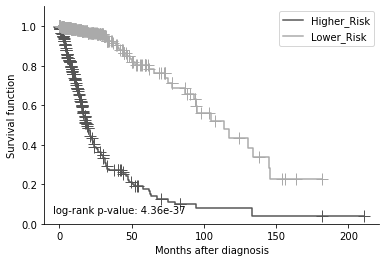

In [83]:
#Kaplan Meier plot
kmf = KaplanMeierFitter()
ax = plt.subplot(111)
gray_palette = sns.color_palette("gray", 2)
ax = kmf.fit(T[group1], E[group1], label=f"Higher_Risk").plot(ax=ax, ci_show=False, show_censors=True, color=gray_palette[0])
ax = kmf.fit(T[group2], E[group2], label=f"Lower_Risk").plot(ax=ax, ci_show=False, show_censors=True, color=gray_palette[1])
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
plt.ylim([0, 1.1])
sns.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)
anchored_text = AnchoredText("log-rank p-value: {:.3}".format(results.p_value), loc=3, frameon=False)
ax.add_artist(anchored_text)
plt.savefig('RiskScore_DF_Filt_gray.png', dpi=600, bbox_inches='tight')

# Transcriptome Analysis # 

In [93]:
selected_gene_data

,SEC24D,ASAH1,PPP1CA,ALOX5AP,ANGPTL4,ELOVL1,LGMN,PNPLA4,GLA,RAN,...,MED7,MED10,CAV1,HEXB,ECHS1,MED18,time,event,risk_score,Risk_Group
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,9.457701,12.348019,11.145283,10.373309,10.674498,10.407661,10.436742,5.487654,9.066014,11.788430,...,7.005189,8.987828,11.098326,10.289097,11.017219,7.882793,14.69,1.0,9.074635,Higher_Risk
tcga-02-0055,11.297265,11.902756,11.816066,12.040068,11.384860,10.978066,11.085067,8.475699,9.954620,12.445422,...,7.893007,9.411827,13.034391,12.419435,10.992429,8.906554,2.49,1.0,11.118284,Higher_Risk
tcga-02-2483,8.269602,11.968978,11.816318,9.146043,11.399054,9.890300,11.806573,5.650693,9.206054,12.977688,...,7.463233,8.821963,10.794107,10.559654,10.602148,8.275510,15.28,0.0,9.819448,Higher_Risk
tcga-02-2485,8.462940,11.987941,11.169519,8.262766,7.818354,9.737770,10.804976,8.460992,8.407369,12.258566,...,7.313315,8.752978,10.779797,10.203383,10.282206,7.749790,15.41,0.0,8.962869,Higher_Risk
tcga-02-2486,9.280658,12.631709,11.607398,12.469629,12.393521,11.351384,11.634479,7.199193,9.443651,12.453409,...,8.418161,9.635032,12.526946,12.169747,11.133753,8.965784,16.16,0.0,10.583610,Higher_Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,6.966926,12.027645,10.715315,8.114357,8.026550,9.537614,9.999280,6.663145,7.470500,11.496035,...,7.316587,8.764684,7.049727,8.600372,11.076421,7.628930,43.28,0.0,6.438134,Lower_Risk
tcga-wy-a85b,7.922941,12.846364,10.995135,8.676692,4.690283,9.882738,11.772784,5.123240,8.057185,11.529064,...,7.040777,8.469890,7.628880,9.294154,10.721867,7.870853,32.89,0.0,6.287497,Lower_Risk
tcga-wy-a85c,6.714611,12.298052,10.343906,7.600769,8.787137,8.990916,9.896338,6.003607,7.657353,11.396580,...,7.003607,8.632313,9.552122,8.227049,10.527967,7.490345,28.39,0.0,6.398062,Lower_Risk


In [94]:
dfRisk = selected_gene_data[['Risk_Group']]

In [95]:
dfRisk

,Risk_Group
hybridization ref,
tcga-02-0047,Higher_Risk
tcga-02-0055,Higher_Risk
tcga-02-2483,Higher_Risk
tcga-02-2485,Higher_Risk
tcga-02-2486,Higher_Risk
...,...
tcga-wy-a85a,Lower_Risk
tcga-wy-a85b,Lower_Risk
tcga-wy-a85c,Lower_Risk


In [96]:
dfRisk.reset_index()

,hybridization ref,Risk_Group
0,tcga-02-0047,Higher_Risk
1,tcga-02-0055,Higher_Risk
2,tcga-02-2483,Higher_Risk
3,tcga-02-2485,Higher_Risk
4,tcga-02-2486,Higher_Risk
...,...,...
687,tcga-wy-a85a,Lower_Risk
688,tcga-wy-a85b,Lower_Risk
689,tcga-wy-a85c,Lower_Risk
690,tcga-wy-a85d,Lower_Risk


In [129]:
#dfS

In [51]:
#dfLip = dfLip.drop(columns='gene_id', index=1)

In [52]:
#dfLip.set_index('hybridization ref', inplace =True)

In [97]:
dfLip = df.apply(pd.to_numeric)

In [98]:
dfLip

,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,?
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,10.006052,10.453281,...,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409,-inf
tcga-02-0055,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,10.410639,9.965178,...,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141,-inf
tcga-02-2483,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,9.920152,9.440623,...,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370,-inf
tcga-02-2485,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,10.358494,9.367363,...,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192,-inf
tcga-02-2486,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,10.534825,8.983272,...,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,10.008181,...,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245,-inf
tcga-wy-a85b,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,9.937575,...,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944,-inf
tcga-wy-a85c,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,10.148817,...,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872,-inf


In [99]:
dfLog= dfLip #dfLog = np.log2(dfLip)

In [100]:
# Assuming your DataFrame is called df
threshold1 = 0  # Set the threshold as desired

# Calculate the count of -inf values in each column
inf_counts1 = (dfLog == -np.inf).sum()

# Filter columns based on the threshold
filtered_columns = inf_counts1[inf_counts1 <= threshold1].index

# Create a new DataFrame with the filtered columns
filtered_dfLog = dfLog[filtered_columns]

In [101]:
filtered_dfLog

,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,10.006052,10.453281,...,8.171274,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409
tcga-02-0055,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,10.410639,9.965178,...,8.518233,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141
tcga-02-2483,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,9.920152,9.440623,...,9.106813,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370
tcga-02-2485,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,10.358494,9.367363,...,8.419459,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192
tcga-02-2486,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,10.534825,8.983272,...,8.716757,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,10.008181,...,7.722039,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245
tcga-wy-a85b,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,9.937575,...,8.566388,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944
tcga-wy-a85c,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,10.148817,...,8.972255,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872


In [102]:
# Check for duplicate columns
duplicated_columns = filtered_dfLog.columns[filtered_dfLog.columns.duplicated()]

# Remove duplicated columns
df_filteredSing = filtered_dfLog.loc[:, ~filtered_dfLog.columns.duplicated()]

In [103]:
df_filteredSing

,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,10.006052,10.453281,...,8.171274,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409
tcga-02-0055,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,10.410639,9.965178,...,8.518233,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141
tcga-02-2483,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,9.920152,9.440623,...,9.106813,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370
tcga-02-2485,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,10.358494,9.367363,...,8.419459,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192
tcga-02-2486,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,10.534825,8.983272,...,8.716757,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,10.008181,...,7.722039,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245
tcga-wy-a85b,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,9.937575,...,8.566388,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944
tcga-wy-a85c,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,10.148817,...,8.972255,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872


In [34]:
#df = df_filteredSing.to_csv('LIHC_RSEM_genes_normalized_Log.csv')

In [150]:
#df = pd.read_csv('LIHC_RSEM_genes_normalized_Log.csv')

In [104]:
dfgen = df_filteredSing.reset_index()

In [142]:
#df = df.reset_index()

In [143]:
#dfdro = dflipR.drop(columns='gene_id', index=1)

In [105]:
dfRisk = dfRisk.reset_index()

In [106]:
dfRisk

,hybridization ref,Risk_Group
0,tcga-02-0047,Higher_Risk
1,tcga-02-0055,Higher_Risk
2,tcga-02-2483,Higher_Risk
3,tcga-02-2485,Higher_Risk
4,tcga-02-2486,Higher_Risk
...,...,...
687,tcga-wy-a85a,Lower_Risk
688,tcga-wy-a85b,Lower_Risk
689,tcga-wy-a85c,Lower_Risk
690,tcga-wy-a85d,Lower_Risk


In [149]:
#df = df.reset_index()

In [107]:
dfRna = dfRisk.join(dfgen.set_index('hybridization ref'),on='hybridization ref')

In [108]:
dfRna.dropna()

,hybridization ref,Risk_Group,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
0,tcga-02-0047,Higher_Risk,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,...,8.171274,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409
1,tcga-02-0055,Higher_Risk,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,...,8.518233,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141
2,tcga-02-2483,Higher_Risk,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,...,9.106813,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370
3,tcga-02-2485,Higher_Risk,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,...,8.419459,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192
4,tcga-02-2486,Higher_Risk,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,...,8.716757,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,tcga-wy-a85a,Lower_Risk,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,...,7.722039,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245
688,tcga-wy-a85b,Lower_Risk,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,...,8.566388,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944
689,tcga-wy-a85c,Lower_Risk,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,...,8.972255,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872
690,tcga-wy-a85d,Lower_Risk,8.234853,4.680381,3.881048,13.509668,6.077974,9.913633,8.937044,8.249069,...,8.104064,5.639724,6.806490,5.129691,8.286004,10.507908,10.256067,10.736499,10.481282,9.590967


In [109]:
dfRna.set_index('hybridization ref', inplace =True)

In [110]:
dfRna

,Risk_Group,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,Higher_Risk,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,10.006052,...,8.171274,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409
tcga-02-0055,Higher_Risk,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,10.410639,...,8.518233,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141
tcga-02-2483,Higher_Risk,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,9.920152,...,9.106813,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370
tcga-02-2485,Higher_Risk,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,10.358494,...,8.419459,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192
tcga-02-2486,Higher_Risk,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,10.534825,...,8.716757,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,Lower_Risk,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,...,7.722039,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245
tcga-wy-a85b,Lower_Risk,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,...,8.566388,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944
tcga-wy-a85c,Lower_Risk,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,...,8.972255,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872


In [111]:
group_high_risk = (dfRna["Risk_Group"] == "Higher_Risk")
group_low_risk = (dfRna["Risk_Group"] == "Lower_Risk")

In [112]:
#gene_expression_df= dfRna.drop(columns=['index'])

In [113]:
gene_expression_df = dfRna.iloc[:, 1:]


In [114]:
gene_expression_df.dropna()

,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,10.006052,10.453281,...,8.171274,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409
tcga-02-0055,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,10.410639,9.965178,...,8.518233,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141
tcga-02-2483,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,9.920152,9.440623,...,9.106813,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370
tcga-02-2485,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,10.358494,9.367363,...,8.419459,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192
tcga-02-2486,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,10.534825,8.983272,...,8.716757,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,10.008181,...,7.722039,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245
tcga-wy-a85b,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,9.937575,...,8.566388,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944
tcga-wy-a85c,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,10.148817,...,8.972255,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872


In [163]:
A1BG = gene_expression_df.loc[group_high_risk]["A1BG"].mean()

In [164]:
A1BG2 = gene_expression_df.loc[group_low_risk]["A1BG"].mean()

In [165]:
foldA1BG = np.exp(A1BG - A1BG2)

In [166]:
foldA1BG

2.5083133820738506

In [115]:
mean_high_risk = gene_expression_df.loc[group_high_risk].mean()
mean_low_risk = gene_expression_df.loc[group_low_risk].mean()

In [116]:
fold_change = np.exp(mean_high_risk - mean_low_risk)

In [117]:
z = np.exp(5 - 8)

In [189]:
z

0.049787068367863944

In [118]:
fold_change

A1BG      2.074594
A2BP1     0.233217
A2LD1     3.902491
A2M       2.216360
A4GALT    1.362711
            ...   
ZXDC      0.789982
ZYG11B    0.879137
ZYX       3.379303
ZZEF1     0.665033
ZZZ3      1.289924
Length: 13538, dtype: float64

In [119]:
# Create a new DataFrame with gene names and fold change values
fold_change_df = pd.DataFrame({'gene': gene_expression_df.columns, 'fold_change': fold_change})

# Sort the DataFrame by fold change values in descending order
fold_change_df = fold_change_df.sort_values('fold_change', ascending=False)

# Reset the index of the DataFrame
fold_change_df = fold_change_df.reset_index(drop=True)

# Print the fold change DataFrame
print(fold_change_df)

         gene  fold_change
0      CHI3L1   350.653755
1       TIMP1    48.165775
2        NNMT    46.761953
3      IGFBP2    45.965936
4        EMP3    45.160803
...       ...          ...
13533  CRTAC1     0.055194
13534    JPH3     0.049775
13535   SMOC1     0.044501
13536    CUX2     0.034431
13537   SFRP2     0.025082

[13538 rows x 2 columns]


In [120]:
fold_change_df

,gene,fold_change
0,CHI3L1,350.653755
1,TIMP1,48.165775
2,NNMT,46.761953
3,IGFBP2,45.965936
4,EMP3,45.160803
...,...,...
13533,CRTAC1,0.055194
13534,JPH3,0.049775
13535,SMOC1,0.044501
13536,CUX2,0.034431


In [121]:
fold_change_df.dropna()

,gene,fold_change
0,CHI3L1,350.653755
1,TIMP1,48.165775
2,NNMT,46.761953
3,IGFBP2,45.965936
4,EMP3,45.160803
...,...,...
13533,CRTAC1,0.055194
13534,JPH3,0.049775
13535,SMOC1,0.044501
13536,CUX2,0.034431


In [122]:
fold_change_df['log2_FC'] = np.log2(fold_change_df['fold_change'])

In [123]:
fold_change_df

,gene,fold_change,log2_FC
0,CHI3L1,350.653755,8.453903
1,TIMP1,48.165775,5.589936
2,NNMT,46.761953,5.547263
3,IGFBP2,45.965936,5.522493
4,EMP3,45.160803,5.496999
...,...,...,...
13533,CRTAC1,0.055194,-4.179343
13534,JPH3,0.049775,-4.328423
13535,SMOC1,0.044501,-4.490004
13536,CUX2,0.034431,-4.860133


In [124]:
fold_change_df.sort_values('gene').dropna()

,gene,fold_change,log2_FC
1676,A1BG,2.074594,1.052829
13322,A2BP1,0.233217,-2.100253
548,A2LD1,3.902491,1.964395
1507,A2M,2.216360,1.148192
3855,A4GALT,1.362711,0.446479
...,...,...,...
9757,ZXDC,0.789982,-0.340108
8682,ZYG11B,0.879137,-0.185839
721,ZYX,3.379303,1.756726
11036,ZZEF1,0.665033,-0.588501


In [125]:
fold_change_df = fold_change_df[['gene', 'log2_FC']]

In [126]:
fold_change_df_Tra = fold_change_df.T

In [127]:
fold_change_df_Tra.columns=fold_change_df_Tra.iloc[0]

In [128]:
fold_change_Tra = fold_change_df_Tra[1:]

In [129]:
fold_change_Tra.apply(pd.to_numeric)

gene,CHI3L1,TIMP1,NNMT,IGFBP2,EMP3,PDPN,MOXD1,SERPINA3,CHI3L2,METTL7B,...,SHANK2,GFRA1,ELFN2,AGXT2L1,INA,CRTAC1,JPH3,SMOC1,CUX2,SFRP2
log2_FC,8.453903,5.589936,5.547263,5.522493,5.496999,5.435746,5.113188,5.111384,5.109352,5.081451,...,-3.816047,-3.932279,-3.941454,-4.059187,-4.169163,-4.179343,-4.328423,-4.490004,-4.860133,-5.317175


In [130]:
dfRna

,Risk_Group,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-02-0047,Higher_Risk,6.965864,7.934455,5.783258,15.053774,5.180474,8.865786,8.912540,7.867686,10.006052,...,8.171274,8.023537,8.659774,6.025751,8.477739,10.114814,10.237409,11.917362,10.448212,9.237409
tcga-02-0055,Higher_Risk,8.613988,7.101725,6.392558,15.387891,8.929958,9.216296,8.309745,6.640820,10.410639,...,8.518233,8.869007,7.939874,5.413015,8.130871,9.247236,9.852462,13.487015,9.243237,9.488141
tcga-02-2483,Higher_Risk,8.086679,6.794793,5.110079,14.362116,6.442375,10.104049,8.945699,8.017969,9.920152,...,9.106813,9.414139,9.386141,4.279434,8.665767,9.758689,10.239186,12.306861,9.700586,9.462370
tcga-02-2485,Higher_Risk,6.391336,8.006427,6.980547,12.928987,7.278339,9.985571,8.249283,7.569856,10.358494,...,8.419459,8.782624,8.787592,5.749789,8.099536,10.394156,10.063395,12.313720,10.154215,9.452192
tcga-02-2486,Higher_Risk,6.758305,2.093662,7.573878,15.322331,5.456228,9.454976,8.614979,7.762038,10.534825,...,8.716757,7.381015,6.217041,4.986743,7.630600,9.349699,9.429687,12.929258,9.293331,9.042860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,Lower_Risk,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,...,7.722039,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245
tcga-wy-a85b,Lower_Risk,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,...,8.566388,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944
tcga-wy-a85c,Lower_Risk,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,...,8.972255,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872


In [131]:
high_risk_data = dfRna[dfRna['Risk_Group'] == 'Higher_Risk'].dropna()
low_risk_data = dfRna[dfRna['Risk_Group'] == 'Lower_Risk'].dropna()

In [204]:
low_risk_data['A1BG'].describe()

count    359.000000
mean       6.124947
std        1.088456
min        2.924100
25%        5.437691
50%        6.228590
75%        6.892933
max       10.077935
Name: A1BG, dtype: float64

In [132]:
low_risk_data

,Risk_Group,A1BG,A2BP1,A2LD1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-26-1442,Lower_Risk,6.136720,8.685244,5.444952,15.028348,7.171983,9.601051,8.190229,7.872826,9.514745,...,8.031591,6.626733,6.511639,5.726907,8.627116,10.073618,10.317809,11.811847,9.934428,8.882476
tcga-cs-4938,Lower_Risk,6.556268,4.501809,3.753219,13.851721,6.198129,9.191933,7.949042,8.216560,9.717743,...,8.108862,6.324875,5.653808,6.004306,9.031164,10.357020,10.546605,10.642872,10.194518,9.707644
tcga-cs-4942,Lower_Risk,6.218264,8.525568,5.683929,14.234061,5.468932,9.131599,8.581370,8.822077,9.054832,...,8.323799,6.907264,7.543072,6.848309,8.827582,10.106461,10.631322,11.112787,10.475607,9.465404
tcga-cs-5394,Lower_Risk,5.246632,4.302977,2.924955,13.170205,5.528862,9.426663,8.122510,8.268960,9.121644,...,8.042389,7.838000,7.769066,7.009052,9.250852,10.549620,10.453760,10.819882,11.197387,8.725259
tcga-cs-6290,Lower_Risk,7.777265,4.178316,6.194625,14.399123,6.889286,9.191139,8.259704,7.590129,9.360591,...,8.101147,6.413386,5.945870,6.014817,8.545886,10.099448,10.135279,11.174823,10.415810,9.367198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-wy-a85a,Lower_Risk,6.291432,7.483324,4.824228,13.184639,5.764683,9.870973,8.754140,8.700235,9.119842,...,7.722039,6.670415,6.601746,5.750609,8.455393,10.302788,10.542729,10.548333,10.603704,9.376245
tcga-wy-a85b,Lower_Risk,6.421536,5.427247,4.941444,14.138290,5.524857,9.484696,8.158429,8.869526,9.472514,...,8.566388,7.914912,8.448726,5.912674,8.974449,10.396258,10.495487,10.621018,10.719292,9.708944
tcga-wy-a85c,Lower_Risk,6.976708,5.490345,4.523280,13.416664,6.535535,9.876404,8.416345,8.902511,9.138393,...,8.972255,6.595171,6.286415,6.255880,9.052172,10.603804,10.857780,10.912640,10.970199,9.829872


In [133]:
import pingouin as pg

differential_genes = []

# Iterate over each gene
for gene in gene_expression_df.columns:
    high_risk_expression = high_risk_data[gene]
    low_risk_expression = low_risk_data[gene]
    
    # Perform the statistical test
    t_statistic, p_value = pg.ttest(high_risk_expression, low_risk_expression)
    
    if p_value < 0.05:
        differential_genes.append(gene)

# Perform multiple testing correction (FDR)
corrected_p_values = pg.multicomp(pvals=differential_genes, method='fdr_bh')
significant_genes = [gene for gene, p_value in zip(differential_genes, corrected_p_values) if p_value < 0.05]


C:\Users\Hennrique\miniconda3\envs\DS_env\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.1, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


ValueError: too many values to unpack (expected 2)

C:\Users\Hennrique\miniconda3\envs\DS_env\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [134]:
differential_genes = []
p_values = []

for gene in gene_expression_df.columns:
    high_risk_expression = high_risk_data[gene]
    low_risk_expression = low_risk_data[gene]

    # Perform the statistical test
    t_statistic, p_value = ttest_ind(high_risk_expression, low_risk_expression)
    # Alternatively, you can use the ranksums test for non-parametric analysis
    # stat, p_value = ranksums(high_risk_expression, low_risk_expression)

    if p_value < 0.05:
        differential_genes.append(gene)
        p_values.append(p_value)

# Apply multiple testing correction using the Benjamini-Hochberg procedure
adjusted_p_values = smt.multipletests(p_values, method='fdr_bh')[1]

# Filter differentially expressed genes based on adjusted p-values
significant_genes = [gene for gene, p_adj in zip(differential_genes, adjusted_p_values) if p_adj < 0.05]


In [135]:
import pandas as pd

# Create a dictionary with the data
data = {
    'Gene': significant_genes,
    'p-value': p_values,
    'FDR': adjusted_p_values,
    
}

# Create the DataFrame
result_df = pd.DataFrame(data)

# Print the DataFrame
print(result_df)


         Gene       p-value           FDR
0        A1BG  5.536631e-16  1.081674e-15
1       A2BP1  3.181885e-16  6.277466e-16
2       A2LD1  4.654878e-53  5.002167e-52
3         A2M  1.385309e-33  5.672845e-33
4      A4GALT  6.674850e-06  8.384447e-06
...       ...           ...           ...
11633    ZXDC  3.772960e-18  7.985036e-18
11634  ZYG11B  3.070998e-04  3.529903e-04
11635     ZYX  1.682709e-79  1.108068e-77
11636   ZZEF1  6.426627e-25  1.822888e-24
11637    ZZZ3  1.950405e-10  3.004873e-10

[11638 rows x 3 columns]


In [136]:
dfStats = fold_change_df.join(result_df.set_index('Gene'),on='gene')

In [137]:
dfStats.dropna()

,gene,log2_FC,p-value,FDR
0,CHI3L1,8.453903,5.070215e-117,9.834526e-114
1,TIMP1,5.589936,3.206836e-127,1.866058e-123
2,NNMT,5.547263,2.585154e-90,4.121372e-88
3,IGFBP2,5.522493,4.931316e-118,1.434766e-114
4,EMP3,5.496999,1.155682e-118,4.483274e-115
...,...,...,...,...
13533,CRTAC1,-4.179343,7.664397e-82,5.868306e-80
13534,JPH3,-4.328423,1.076711e-72,4.190889e-71
13535,SMOC1,-4.490004,4.087377e-70,1.258436e-68
13536,CUX2,-4.860133,1.924528e-72,7.225050e-71


In [138]:
dfStats.set_index('gene', inplace=True)

In [139]:
dfStats = dfStats.apply(pd.to_numeric)

In [140]:
dfStats.reset_index().dropna()

,gene,log2_FC,p-value,FDR
0,CHI3L1,8.453903,5.070215e-117,9.834526e-114
1,TIMP1,5.589936,3.206836e-127,1.866058e-123
2,NNMT,5.547263,2.585154e-90,4.121372e-88
3,IGFBP2,5.522493,4.931316e-118,1.434766e-114
4,EMP3,5.496999,1.155682e-118,4.483274e-115
...,...,...,...,...
13533,CRTAC1,-4.179343,7.664397e-82,5.868306e-80
13534,JPH3,-4.328423,1.076711e-72,4.190889e-71
13535,SMOC1,-4.490004,4.087377e-70,1.258436e-68
13536,CUX2,-4.860133,1.924528e-72,7.225050e-71


In [141]:
dfStats['log_p-value'] = -np.log10(dfStats['p-value'])

In [142]:
dfStats = dfStats.reset_index().dropna()

In [143]:
dfStats

,gene,log2_FC,p-value,FDR,log_p-value
0,CHI3L1,8.453903,5.070215e-117,9.834526e-114,116.294974
1,TIMP1,5.589936,3.206836e-127,1.866058e-123,126.493923
2,NNMT,5.547263,2.585154e-90,4.121372e-88,89.587514
3,IGFBP2,5.522493,4.931316e-118,1.434766e-114,117.307037
4,EMP3,5.496999,1.155682e-118,4.483274e-115,117.937162
...,...,...,...,...,...
13533,CRTAC1,-4.179343,7.664397e-82,5.868306e-80,81.115522
13534,JPH3,-4.328423,1.076711e-72,4.190889e-71,71.967901
13535,SMOC1,-4.490004,4.087377e-70,1.258436e-68,69.388555
13536,CUX2,-4.860133,1.924528e-72,7.225050e-71,71.715676


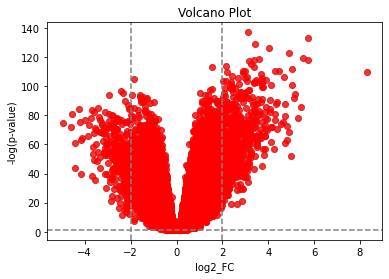

In [217]:
# Reset indices of result_df and dfStats
#result_df.reset_index(drop=True, inplace=True)
dfStats.reset_index(drop=True, inplace=True)

# Create the volcano plot
plt.scatter(dfStats['log2_FC'], -np.log10(dfStats['p-value']), c='gray', alpha=0.5)
plt.scatter(dfStats[dfStats['FDR'] < 0.05]['log2_FC'], -np.log10(dfStats[dfStats['FDR'] < 0.05]['p-value']), c='red', alpha=0.7)

# Set plot labels and title
plt.xlabel('log2_FC')
plt.ylabel('-log(p-value)')
plt.title('Volcano Plot')

# Add significance threshold lines
plt.axvline(x=2, color='gray', linestyle='--')
plt.axvline(x=-2, color='gray', linestyle='--')
plt.axhline(y=-np.log10(0.05), color='gray', linestyle='--')

# Show the plot
plt.show()


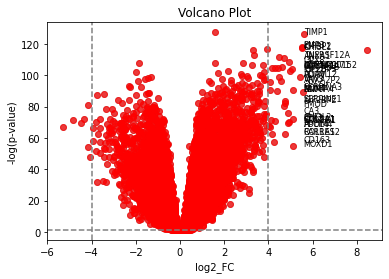

In [220]:

# Reset indices of result_df and dfStats
#result_df.reset_index(drop=True, inplace=True)
dfStats.reset_index(drop=True, inplace=True)

# Create the volcano plot
plt.scatter(dfStats['log2_FC'], -np.log10(dfStats['p-value']), c='gray', alpha=0.5)
significant_genes = dfStats[dfStats['log2_FC'] >= 4]['gene']
Lsignificant_genes = dfStats[dfStats['log2_FC'] <= -4]['gene']
significant_fc = dfStats[dfStats['FDR'] < 0.05]['log2_FC']
significant_pval = -np.log10(dfStats[dfStats['FDR'] < 0.05]['p-value'])
plt.scatter(significant_fc, significant_pval, c='red', alpha=0.7)

# Set plot labels and title
plt.xlabel('log2_FC')
plt.ylabel('-log(p-value)')
plt.title('Volcano Plot')

# Add significance threshold lines
plt.axvline(x=4, color='gray', linestyle='--')
plt.axvline(x=-4, color='gray', linestyle='--')
plt.axhline(y=-np.log10(0.05), color='gray', linestyle='--')

# Add gene name annotations
for i in range(len(significant_genes)):
    plt.annotate(significant_genes[i], (significant_fc[1], significant_pval[i]), fontsize=8)

# Show the plot
plt.show()




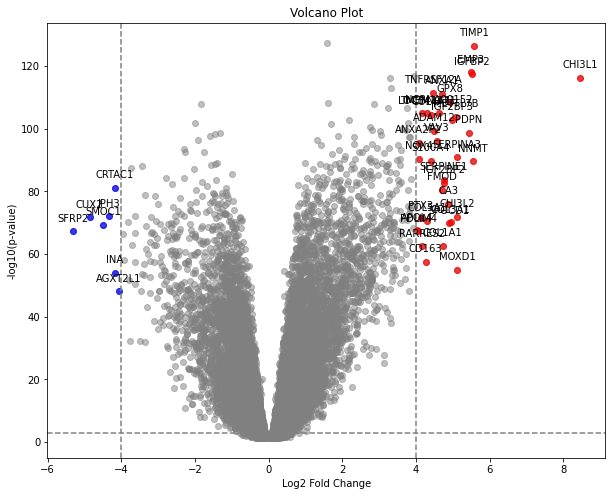

In [144]:
# Define the log2 fold change threshold for extreme values
#fold_change_threshold = 3

# Filter genes based on log2 fold change
extreme_genes_pos = dfStats[dfStats['log2_FC'] >= 4]
extreme_genes_neg = dfStats[dfStats['log2_FC'] <= -4]

# Create the volcano plot
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the figsize as per your requirement
ax.scatter(dfStats['log2_FC'], -np.log10(dfStats['p-value']), color='gray', alpha=0.5)
ax.scatter(extreme_genes_pos['log2_FC'], -np.log10(extreme_genes_pos['p-value']), color='red', alpha=0.7, label='Positive Fold Change')
ax.scatter(extreme_genes_neg['log2_FC'], -np.log10(extreme_genes_neg['p-value']), color='blue', alpha=0.7, label='Negative Fold Change')

# Set plot labels and title
ax.set_xlabel('Log2 Fold Change')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano Plot')

# Add significance threshold lines
plt.axvline(x=4, color='gray', linestyle='--')
plt.axvline(x=-4, color='gray', linestyle='--')
plt.axhline(y=-np.log10(0.001), color='gray', linestyle='--')

# Show the gene names for extreme genes
for gene, x, y in zip(extreme_genes_pos['gene'], extreme_genes_pos['log2_FC'], -np.log10(extreme_genes_pos['p-value'])):
    ax.annotate(gene, (x, y), textcoords="offset points", xytext=(0,10), ha='center')
for gene, x, y in zip(extreme_genes_neg['gene'], extreme_genes_neg['log2_FC'], -np.log10(extreme_genes_neg['p-value'])):
    ax.annotate(gene, (x, y), textcoords="offset points", xytext=(0,10), ha='center')

# Display the legend
#ax.legend()

# Display the plot
#plt.show()
#plt.savefig('Volc_Lip_GBMLGGDF_RISK.png', dpi=300, bbox_inches='tight')
plt.show()

In [145]:
dfStats

,gene,log2_FC,p-value,FDR,log_p-value
0,CHI3L1,8.453903,5.070215e-117,9.834526e-114,116.294974
1,TIMP1,5.589936,3.206836e-127,1.866058e-123,126.493923
2,NNMT,5.547263,2.585154e-90,4.121372e-88,89.587514
3,IGFBP2,5.522493,4.931316e-118,1.434766e-114,117.307037
4,EMP3,5.496999,1.155682e-118,4.483274e-115,117.937162
...,...,...,...,...,...
13533,CRTAC1,-4.179343,7.664397e-82,5.868306e-80,81.115522
13534,JPH3,-4.328423,1.076711e-72,4.190889e-71,71.967901
13535,SMOC1,-4.490004,4.087377e-70,1.258436e-68,69.388555
13536,CUX2,-4.860133,1.924528e-72,7.225050e-71,71.715676


In [146]:
Up_significant_genes_list = dfStats[(dfStats['FDR'] < 0.05) & (dfStats['log2_FC'] >= 3.0)]['gene'].tolist()

In [147]:
Down_significant_genes_list = dfStats[(dfStats['FDR'] < 0.05) & (dfStats['log2_FC'] < -3.0)]['gene'].tolist()

In [148]:
len(Up_significant_genes_list)

152

In [147]:
df_statt = dfStats[(dfStats['FDR'] < 0.05) & (dfStats['log2_FC'] > 1)]

In [139]:
df_stattNeg = dfStats[(dfStats['FDR'] < 0.05) & (dfStats['log2_FC'] <= -1)]

In [150]:
df_statt

,gene,log2_FC,p-value,FDR,log_p-value
0,FOSL1,1.999305,2.417109e-22,4.054942e-20,21.616704
1,CD109,1.941490,6.591940e-36,5.529319e-32,35.180987
2,FLNC,1.872142,5.622715e-22,8.733950e-20,21.250054
3,RSPO3,1.865506,3.171875e-18,1.537901e-16,17.498684
4,SERPINE1,1.839484,8.124785e-29,9.735814e-26,28.090188
...,...,...,...,...,...
142,UBASH3B,1.015040,4.271182e-12,4.385150e-11,11.369452
143,PRKG1,1.011355,1.863502e-09,1.065051e-08,8.729670
144,SULF1,1.007560,5.486639e-08,2.253259e-07,7.260694
145,CHST11,1.003156,5.608072e-22,8.733950e-20,21.251186


In [142]:
df_stattNeg

,gene,log2_FC,p-value,FDR,log_p-value
13245,RTN4RL2,-1.002859,2.923225e-06,8.325979e-06,5.534138
13246,MYO15B,-1.003378,1.055476e-09,6.387688e-09,8.976552
13247,ERO1LB,-1.004946,2.828805e-12,3.030398e-11,11.548397
13248,PLEKHB1,-1.005412,6.258964e-14,9.722257e-13,13.203498
13249,C16orf93,-1.012710,1.438236e-16,4.262872e-15,15.842170
...,...,...,...,...,...
13420,KIAA1324,-1.861805,1.005541e-14,1.930086e-13,13.997600
13421,CYP2B7P1,-1.963030,3.310266e-12,3.488256e-11,11.480137
13422,CACNA2D2,-1.966216,4.114309e-10,2.717387e-09,9.385703
13423,LOC283174,-2.187356,8.083829e-21,8.696765e-19,20.092383


In [452]:
from PIL import Image
from io import BytesIO
from selenium import webdriver

# Assuming you have a DataFrame called df
styled_df = df_statt.style

# Render the styled DataFrame as HTML
html = styled_df.render()

# Use selenium to render the HTML and capture a screenshot
driver = webdriver.Chrome()
driver.set_window_size(800, 600)  # Set the window size
driver.get("data:text/html;charset=utf-8," + html)  # Load the HTML content
screenshot = driver.get_screenshot_as_png()  # Capture the screenshot
driver.quit()

# Convert the screenshot to an image
image = Image.open(BytesIO(screenshot))

# Save the image
image.save("dataframe_up.png")

C:\Users\Hennrique\AppData\Local\Temp\ipykernel_6876\4056197521.py:9: FutureWarning: this method is deprecated in favour of `Styler.to_html()`
  html = styled_df.render()


In [299]:
top_genes

,gene,fold_change,p-value,FDR,log_p-value
0,SILV,18.002880,1.701749e-14,1.249283e-13,13.769105
1,VGF,8.373473,3.105213e-09,9.416349e-09,8.507909
2,MGAT5B,6.472349,1.575917e-16,1.755017e-15,15.802467
3,CDH3,6.355037,1.080959e-12,5.714188e-12,11.966191
4,BAIAP2L2,5.991376,2.321533e-21,7.775404e-20,20.634225
5,TSPAN10,5.959436,7.876180e-12,3.606969e-11,11.103684
6,SLC16A6,5.676795,4.567028e-11,1.838280e-10,10.340366
7,CA14,5.519965,6.488685e-09,1.865549e-08,8.187843
8,LAMA1,5.273796,2.235309e-12,1.128466e-11,11.650662
9,GMPR,4.574371,5.361812e-12,2.531149e-11,11.270688


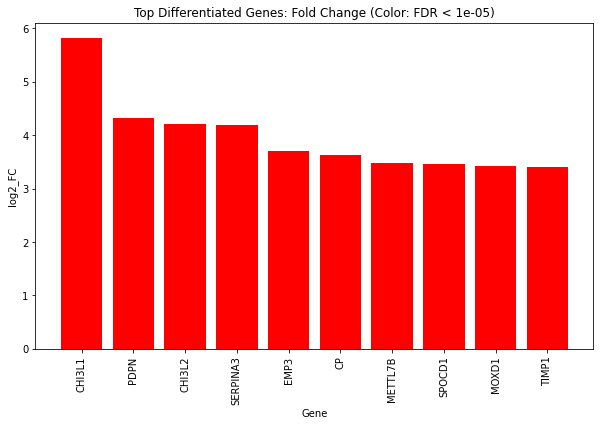

In [351]:
threshold = 1e-5
significant_genes = df_statt[df_statt['FDR'] < threshold]

# Set up the figure
plt.figure(figsize=(10, 6))

# Plot the fold change values
colors = np.where(significant_genes['FDR'] < threshold, 'red', 'gray')
plt.bar(np.arange(len(significant_genes)), significant_genes['log2_FC'], color=colors)

# Customize the plot
plt.xticks(np.arange(len(significant_genes)), significant_genes['gene'], rotation=90)
plt.xlabel('Gene')
plt.ylabel('log2_FC')
plt.title('Top Differentiated Genes: Fold Change (Color: FDR < {})'.format(threshold))
ax.invert_yaxis() 
# Show the plot
plt.show()

In [433]:
#significant_genes_list

In [149]:
# Save the list of significant genes to a text file
with open('Up_MGMTUP_gened_LassoLipRis.txt', 'w') as file:
    file.write('\n'.join(Up_significant_genes_list))

In [150]:
# Save the list of significant genes to a text file
with open('Down_MGMTUP_gened_LassoLipRis.txt', 'w') as file:
    file.write('\n'.join(Down_significant_genes_list))

# DRAFT #

In [152]:
corr_matrix = filtered_df.corr()

# Create a mask to identify highly correlated variables
corr_threshold = 0.5  # Set the correlation threshold as desired
corr_mask = corr_matrix.abs() >= corr_threshold

# Create a set to store the columns to remove
cols_to_remove = set()

# Iterate over the correlation matrix and identify columns to remove
for col in corr_matrix.columns:
    correlated_cols = corr_matrix.index[corr_matrix[col].abs() >= corr_threshold].tolist()
    if len(correlated_cols) > 1:
        cols_to_remove.update(correlated_cols[1:])

# Remove the highly correlated columns from the DataFrame
df_filtered = filtered_df.drop(cols_to_remove, axis=1)

In [153]:
df_filtered

,AACS,ABCA1,ABCC1,ABCC3,ABCD1,ABHD3,ABHD4,ABHD5,ACAA2,ACACA,...,TM7SF2,TMEM86B,TNFAIP8L1,TNFRSF21,TRIB3,TXNRD1,VAPA,VAPB,patient.days_to_death,event
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-3n-a9wb,9.929796,9.741837,9.402795,3.549965,11.935758,8.267528,8.644730,8.489650,9.935163,10.385911,...,9.241773,6.371468,6.269417,8.559267,10.090732,10.879959,11.213098,9.821916,518.0,1.0
tcga-3n-a9wc,7.134631,10.143630,10.308215,6.503598,10.828397,9.112827,9.140801,8.497201,9.591812,11.039321,...,5.222580,6.134632,6.522624,11.582588,10.239447,11.988912,11.109160,10.530085,1856.0,0.0
tcga-3n-a9wd,10.467201,10.275794,11.114868,6.694129,9.292208,8.610213,9.851926,9.049269,9.721051,9.144550,...,10.239014,6.492989,6.808085,9.999160,10.577777,9.758152,11.510631,10.248298,395.0,1.0
tcga-bf-a1pu,8.837525,8.089597,10.322879,3.698996,10.999121,7.244349,10.688818,8.675132,9.872925,10.814302,...,8.354349,6.943123,7.574286,12.512859,10.075774,10.271887,11.137166,11.269802,387.0,0.0
tcga-bf-a1pv,9.328354,10.075733,6.570446,5.773263,10.330365,8.947560,9.088078,8.099913,11.031114,10.812631,...,5.781124,5.725169,7.978662,9.517306,9.707743,10.883271,11.572146,10.462134,14.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-yg-aa3o,9.195732,11.316088,10.732215,5.673418,11.351825,7.418006,8.758067,8.002968,9.370177,10.543863,...,6.711137,6.946765,7.183205,10.863896,8.343405,11.592517,10.929868,11.004393,1096.0,0.0
tcga-yg-aa3p,8.246390,10.703947,9.546899,3.898924,10.507841,7.466611,7.080256,7.571351,7.911750,9.933136,...,4.846458,5.534516,6.157660,9.231123,5.500961,11.755796,11.327286,10.049399,439.0,0.0
tcga-z2-a8rt,9.445608,10.287189,9.557441,5.478118,10.571473,7.915717,9.562627,8.538016,10.431101,10.887067,...,5.609909,6.367338,7.198683,11.162547,9.582456,10.914849,10.555956,10.314307,719.0,0.0


In [135]:
from sklearn.linear_model import LassoLarsCV


In [154]:
cph = CoxPHFitter()
cph.fit(df_filtered, duration_col='patient.days_to_death', event_col='event')

C:\Users\Hennrique\miniconda3\envs\DS_env\lib\site-packages\lifelines\fitters\coxph_fitter.py:1608: ConvergenceWarning: Newton-Rhaphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 463 total observations, 309 right-censored observations>

In [155]:
weights = cph.summary['coef']

In [168]:
cph = CoxPHFitter()
cph.fit(df_filtered, duration_col='patient.days_to_death', event_col='event')
#coefficients = cph.coef_
signature_genes = df_filtered.drop(columns=['patient.days_to_death', 'event'])
risk_score = np.dot(signature_genes, weights)
df_filtered['risk_score'] = risk_score

C:\Users\Hennrique\miniconda3\envs\DS_env\lib\site-packages\lifelines\fitters\coxph_fitter.py:1608: ConvergenceWarning: Newton-Rhaphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


In [172]:
df_filtered

,AACS,ABCA1,ABCC1,ABCC3,ABCD1,ABHD3,ABHD4,ABHD5,ACAA2,ACACA,...,TMEM86B,TNFAIP8L1,TNFRSF21,TRIB3,TXNRD1,VAPA,VAPB,patient.days_to_death,event,risk_score
hybridization ref,,,,,,,,,,,,,,,,,,,,,
tcga-3n-a9wb,9.929796,9.741837,9.402795,3.549965,11.935758,8.267528,8.644730,8.489650,9.935163,10.385911,...,6.371468,6.269417,8.559267,10.090732,10.879959,11.213098,9.821916,518.0,1.0,11.869365
tcga-3n-a9wc,7.134631,10.143630,10.308215,6.503598,10.828397,9.112827,9.140801,8.497201,9.591812,11.039321,...,6.134632,6.522624,11.582588,10.239447,11.988912,11.109160,10.530085,1856.0,0.0,10.742917
tcga-3n-a9wd,10.467201,10.275794,11.114868,6.694129,9.292208,8.610213,9.851926,9.049269,9.721051,9.144550,...,6.492989,6.808085,9.999160,10.577777,9.758152,11.510631,10.248298,395.0,1.0,12.984293
tcga-bf-a1pu,8.837525,8.089597,10.322879,3.698996,10.999121,7.244349,10.688818,8.675132,9.872925,10.814302,...,6.943123,7.574286,12.512859,10.075774,10.271887,11.137166,11.269802,387.0,0.0,8.155920
tcga-bf-a1pv,9.328354,10.075733,6.570446,5.773263,10.330365,8.947560,9.088078,8.099913,11.031114,10.812631,...,5.725169,7.978662,9.517306,9.707743,10.883271,11.572146,10.462134,14.0,0.0,11.696285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tcga-yg-aa3o,9.195732,11.316088,10.732215,5.673418,11.351825,7.418006,8.758067,8.002968,9.370177,10.543863,...,6.946765,7.183205,10.863896,8.343405,11.592517,10.929868,11.004393,1096.0,0.0,10.999434
tcga-yg-aa3p,8.246390,10.703947,9.546899,3.898924,10.507841,7.466611,7.080256,7.571351,7.911750,9.933136,...,5.534516,6.157660,9.231123,5.500961,11.755796,11.327286,10.049399,439.0,0.0,11.927949
tcga-z2-a8rt,9.445608,10.287189,9.557441,5.478118,10.571473,7.915717,9.562627,8.538016,10.431101,10.887067,...,6.367338,7.198683,11.162547,9.582456,10.914849,10.555956,10.314307,719.0,0.0,11.550534


In [170]:
cph.print_summary()

C:\Users\Hennrique\miniconda3\envs\DS_env\lib\site-packages\lifelines\utils\printer.py:62: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return summary_df[columns].to_latex(float_format="%." + str(self.decimals) + "f")


<lifelines.CoxPHFitter: fitted with 463 total observations, 309 right-censored observations>
             duration col = 'patient.days_to_death'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 463
number of events observed = 154
   partial log-likelihood = -634.20
         time fit was run = 2023-06-12 22:53:24 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
AACS       -0.37       0.69       0.40            -1.15             0.41                 0.32                 1.50
ABCA1       0.22       1.24       0.27            -0.31             0.74                 0.73                 2.10
ABCC1      -0.02       0.98       0.37            -0.75             0.72                 0.47                 2.05
ABCC3      -0.09       0.92       0.19            -0.46             0.28                 0.63                 1.33
ABCD1      -0.27       0.76       0.37            -1.00             0.45                 0.37                 1.57
ABHD3       0.27       1.30       0.50            -0.71             1.24                 0.49                 3.46
ABHD4       0.12       1.13       0.47            -0.81             1.05                 0.45                 2.86
ABHD5      -0.47       0.62       0.61            -1.68             0.73                 0.19                 2.08
ACAA2       0.27       1.31       0.50            -0.71             1.25                 0.49                 3.49
ACACA      -0.11       0.90       0.65            -1.37             1.16                 0.25                 3.19
ACACB       0.03       1.03       0.25            -0.46             0.51                 0.63                 1.67
ACAD10      0.36       1.43       0.54            -0.70             1.42                 0.50                 4.13
ACADS      -0.35       0.71       0.42            -1.17             0.48                 0.31                 1.62
ACAT1       0.25       1.28       0.48            -0.69             1.19                 0.50                 3.28
ACAT2       0.18       1.20       0.34            -0.49             0.85                 0.61                 2.34
ACBD4      -0.51       0.60       0.55            -1.59             0.57                 0.20                 1.77
ACBD6      -0.84       0.43       0.66            -2.13             0.46                 0.12                 1.58
ACER3      -0.16       0.85       0.34            -0.84             0.51                 0.43                 1.67
ACHE       -0.19       0.83       0.22            -0.62             0.24                 0.54                 1.27
ACOT1       0.01       1.01       0.44            -0.85             0.86                 0.43                 2.37
ACOT13      0.51       1.66       0.60            -0.67             1.69                 0.51                 5.41
ACOT4       0.03       1.03       0.23            -0.41             0.48                 0.66                 1.61
ACOT9      -0.17       0.85       0.92            -1.97             1.64                 0.14                 5.17
ACOX3      -0.09       0.92       0.51            -1.08             0.91                 0.34                 2.48
ACP6       -0.00       1.00       0.24            -0.47             0.46                 0.63                 1.59
ACSF2      -0.11       0.90       0.20            -0.50             0.28                 0.61                 1.33
ACSL1      -0.09       0.91       0.38            -0.84             0.65                 0.43                 1.92
AGK        -0.08       0.92       0.54            -1.15             0.98                 0.32                 2.67
AGPAT3      0.23       1.26       0.45            -0.66             1.12                 0.52                 3.08
AGPAT4     -0.05       0.95       0.20            -0.44      